Mesh, BCs, and Loads generated successfully.
Number of nodes: 1200
Number of elements: 2212
Number of equations: 2369
Duration for system solution: 0:00:00.850937
Duration for post processing: 0:00:00.250722
Analysis terminated successfully!


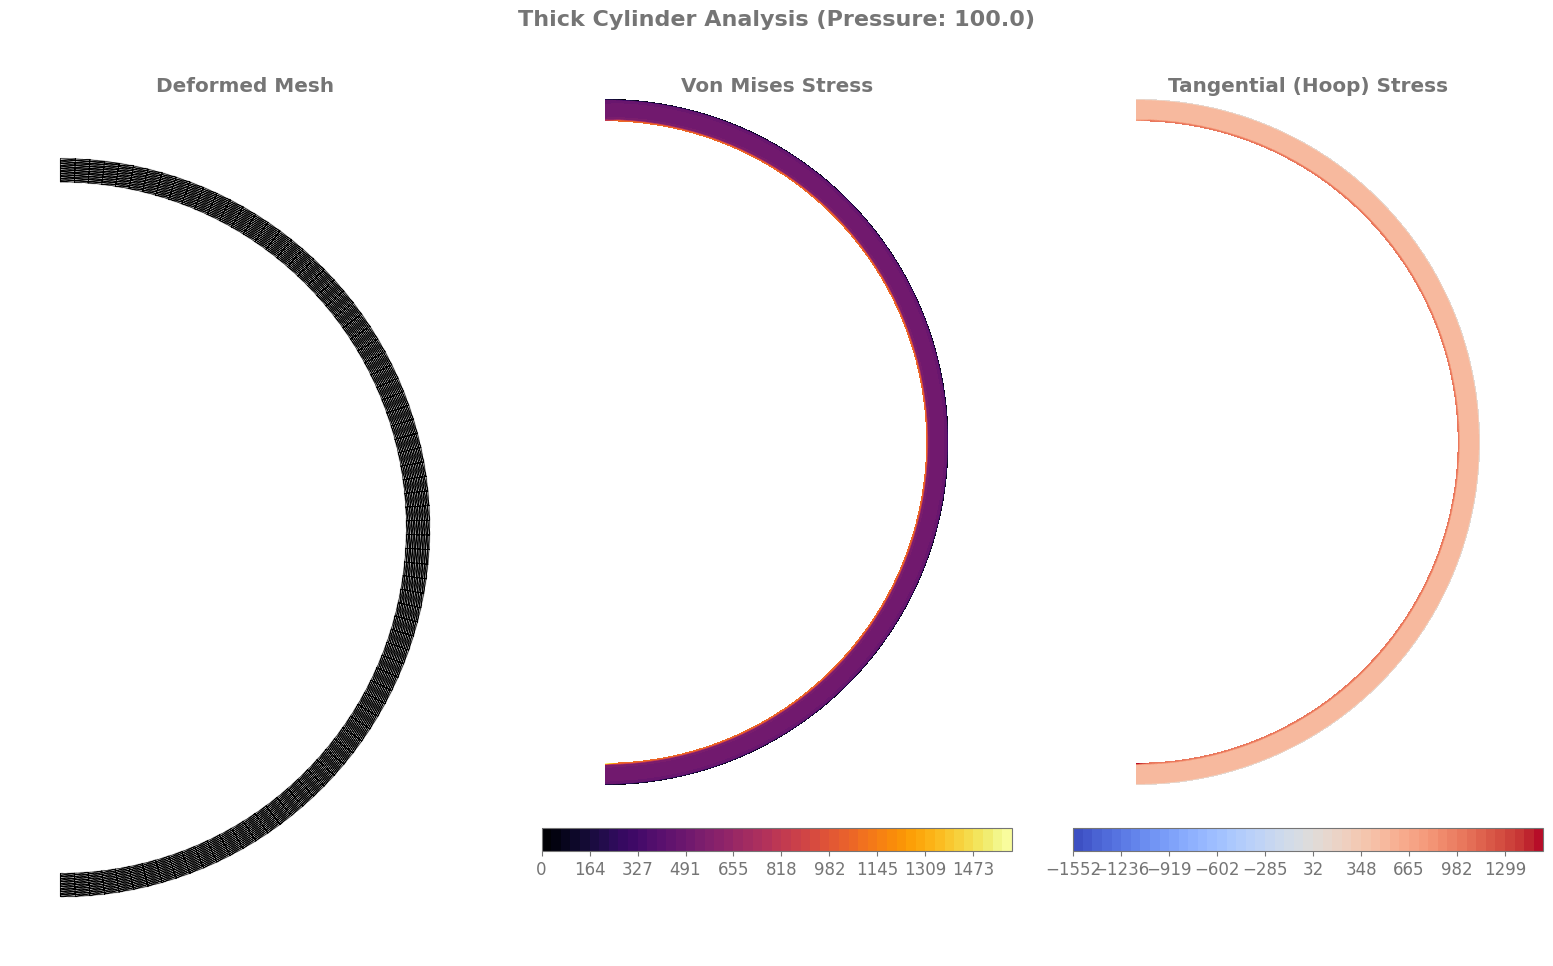

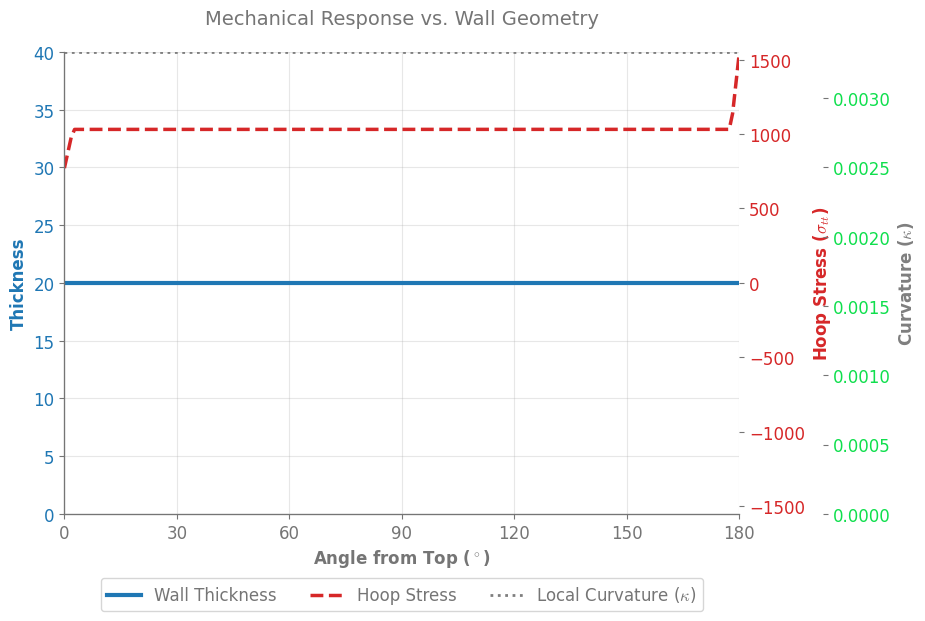

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from solidspy import solids_GUI
import solidspy.preprocesor as pre

# ==============================================================================
# 1. USER CONTROL PANEL
# ==============================================================================
# --- Geometry Parameters ---
r_i_val = 300.0*1   # Inner radius (Major axis along Y)
AR_val = 1   # Aspect Ratio (r_i_val / AR_val = minor axis along X)
t_top_val = 20.0*1    # Minimum thickness at top (0 deg)
t_side_val = t_top_val*1    # Maximum thickness at sides (90 deg)
t_bot_val = t_top_val*1     # Mid thickness at bottom (180 deg)

# --- Mesh Parameters ---
n_theta = 80         # Number of angular divisions (bottom to top)
n_r = 15             # Number of radial divisions (thickness)

# --- Loading ---
internal_pressure = 100.0  # Magnitude of internal pressure

# --- Material Options (Must match mater.txt) ---
# NOTE: To run this correctly as Plane Strain (thick cylinder), ensure your 
# mater.txt file uses Effective Properties: E' = E/(1-v^2), v' = v/(1-v)
# ==============================================================================

# ==============================================================================
# 2. MESH & FILE GENERATION
# ==============================================================================
def generate_and_save_model(r_i, AR, t_top, t_side, t_bot, n_t, n_r, pressure):
    """Generates half-tube mesh, BCs, and Loads, saving them for SolidSpy."""
    
    # --- A. Generate Mesh ---
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)
    
    a, b = r_i / AR, r_i
    A_t = (2*t_side + t_top + t_bot) / 4.0
    B_t = (t_top - t_bot) / 2.0
    C_t = (2*t_side - t_top - t_bot) / 4.0

    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_in = (a * b) / np.sqrt((b * np.cos(theta))**2 + (a * np.sin(theta))**2)
        t_theta = A_t + B_t * np.sin(theta) + C_t * np.cos(2*theta)
        r_out = r_in + r_frac * t_theta
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    triangles = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1, n2 = i*n_t + j, i*n_t + (j + 1)
            n3, n4 = (i + 1)*n_t + j, (i + 1)*n_t + (j + 1)
            triangles.extend([[n1, n3, n2], [n2, n3, n4]])
    triangles = np.array(triangles)

    # --- B. Save Nodes (with BCs) & Elements ---
    min_y = np.min(nodes_y)
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    with open("eles.txt", 'w') as feles:
        for i, tri in enumerate(triangles):
            feles.write(f"{i} 3 0 {tri[0]} {tri[1]} {tri[2]}\n")

    # --- C. Save Pressure Loads ---
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx = nodes_x[n2] - nodes_x[n1]
        dy = nodes_y[n2] - nodes_y[n1]
        
        # Normal pointing into the solid (dy, -dx)
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        
        F_x[n1] += 0.5 * fx_seg; F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg; F_y[n2] += 0.5 * fy_seg

    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")
                
    return nodes_x, nodes_y, triangles

# Generate files based on user inputs
X, Y, tri_elements = generate_and_save_model(
    r_i_val, AR_val, t_top_val, t_side_val, t_bot_val, n_theta, n_r, internal_pressure
)
print("Mesh, BCs, and Loads generated successfully.")


# ==============================================================================
# 3. RUN FEA (SolidSpy)
# ==============================================================================
# Ensure mater.txt exists in the working directory before running this!
disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

# Extract Results
U_x, U_y = disp[:, 0], disp[:, 1]
Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]
von_mises = np.sqrt(Sig_xx**2 - Sig_xx*Sig_yy + Sig_yy**2 + 3*Tau_xy**2)


# ==============================================================================
# 4. POST-PROCESSING (Stress Projection)
# ==============================================================================
# Calculate Tangential (Hoop) Stress based on local geometry
theta_all = np.arctan2(Y, X)
theta_in_raw = np.arctan2(Y[:n_theta], X[:n_theta])
sort_idx = np.argsort(theta_in_raw)

x_in, y_in = X[:n_theta][sort_idx], Y[:n_theta][sort_idx]
theta_in_sorted = theta_in_raw[sort_idx]

# Tangent/Normal calculation
dx_in, dy_in = np.gradient(x_in), np.gradient(y_in)
alpha_inner = np.arctan2(dy_in, dx_in) - (np.pi / 2.0)

# Map normal angle to all nodes
closest_idx = np.argmin(np.abs(theta_all[:, np.newaxis] - theta_in_sorted), axis=1)
alpha_all = alpha_inner[closest_idx]
c, s = np.cos(alpha_all), np.sin(alpha_all)

# Project Stress
Sig_tt = Sig_xx * s**2 + Sig_yy * c**2 - 2 * Tau_xy * s * c


# ==============================================================================
# 5. VISUALIZATION (Consolidated Subplots)
# ==============================================================================
fig = plt.figure(figsize=(16, 10))

# --- Subplot 1: Geometry & Deformation ---
ax1 = plt.subplot(1, 3, 1)
scale = 1  # Deformation scale factor
ax1.triplot(X, Y, tri_elements, color='gray', linestyle='--', alpha=0.3)
ax1.triplot(X + U_x*scale, Y + U_y*scale, tri_elements, color='black', lw=0.5)
ax1.set_title("Deformed Mesh", fontweight='bold')
ax1.axis('equal'); ax1.axis('off')


# --- Subplot 2: Von Mises Stress ---
ax2 = plt.subplot(1, 3, 2)
levels_vm = np.linspace(0, np.max(von_mises), 50)
cont2 = ax2.tricontourf(X, Y, tri_elements, von_mises, levels=levels_vm, cmap='inferno')
ax2.set_title("Von Mises Stress", fontweight='bold')
ax2.axis('equal'); ax2.axis('off')
fig.colorbar(cont2, ax=ax2, orientation='horizontal', pad=0.05)

# --- Subplot 3: Tangential (Hoop) Stress ---
ax3 = plt.subplot(1, 3, 3)
max_tt = np.max(np.abs(Sig_tt))
levels_tt = np.linspace(-max_tt, max_tt, 50)
cont3 = ax3.tricontourf(X, Y, tri_elements, Sig_tt, levels=levels_tt, cmap='coolwarm')
ax3.set_title("Tangential (Hoop) Stress", fontweight='bold')
ax3.axis('equal'); ax3.axis('off')
fig.colorbar(cont3, ax=ax3, orientation='horizontal', pad=0.05)

plt.suptitle(f"Thick Cylinder Analysis (Pressure: {internal_pressure})", fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()
# ==============================================================================
# 6. GEOMETRY (THICKNESS & CURVATURE) vs STRESS CORRELATION
# ==============================================================================
phi_deg = np.linspace(0, 180, 200)
theta_math = np.pi/2 - np.deg2rad(phi_deg) # Top is pi/2, Side is 0, Bottom is -pi/2

# --- 1. Extract Stress Data ---
sig_tt_in_raw = Sig_tt[:n_theta]
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw)
sort_idx2 = np.argsort(phi_in_deg_raw)
sig_tt_smooth = np.interp(phi_deg, phi_in_deg_raw[sort_idx2], sig_tt_in_raw[sort_idx2])

# --- 2. Geometry Profiles ---
# A. Thickness
A_t = (2*t_side_val + t_top_val + t_bot_val) / 4.0
B_t = (t_top_val - t_bot_val) / 2.0
C_t = (2*t_side_val - t_top_val - t_bot_val) / 4.0
thickness = A_t + B_t * np.sin(theta_math) + C_t * np.cos(2*theta_math)

# B. Local Curvature (Kappa)
a = r_i_val / AR_val  # Semi-minor axis (X)
b = r_i_val           # Semi-major axis (Y)
numerator = a * b
denominator = (a**2 * np.sin(theta_math)**2 + b**2 * np.cos(theta_math)**2)**(1.5)
kappa = numerator / denominator

# --- 3. Plotting with Triple Y-Axes ---
fig2, ax_t = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.8) # Make room for the third axis

ax_s = ax_t.twinx() # Second axis for Stress
ax_k = ax_t.twinx() # Third axis for Curvature

# Offset the third axis (Curvature) to the right
ax_k.spines['right'].set_position(('outward', 60))

# Plot lines
line1 = ax_t.plot(phi_deg, thickness, color='#1f77b4', lw=3, label='Wall Thickness')
line2 = ax_s.plot(phi_deg, sig_tt_smooth, color='#d62728', lw=2.5, ls='--', label='Hoop Stress')
line3 = ax_k.plot(phi_deg, kappa, color='#7f7f7f', lw=2, ls=':', label='Local Curvature ($\kappa$)')

# Labeling
ax_t.set_xlabel('Angle from Top ($^\circ$)', fontweight='bold')
ax_t.set_ylabel('Thickness', color='#1f77b4', fontweight='bold')
ax_s.set_ylabel('Hoop Stress ($\sigma_{tt}$)', color='#d62728', fontweight='bold')
ax_k.set_ylabel('Curvature ($\kappa$)', color='#7f7f7f', fontweight='bold')

# Colors and Ticks
ax_t.tick_params(axis='y', labelcolor='#1f77b4')
ax_s.tick_params(axis='y', labelcolor='#d62728')
ax_k.tick_params(axis='y', labelcolor="#0fdf4d")

ax_t.set_xlim(0, 180)
ax_t.set_ylim(0, np.max(thickness)*2)
ax_t.set_xticks(np.arange(0, 181, 30))
ax_t.grid(True, alpha=0.3)

ax_k.set_ylim(0, np.max(kappa))
ax_s.set_ylim(-np.max(sig_tt_smooth), np.max(sig_tt_smooth))

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_t.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('Mechanical Response vs. Wall Geometry', fontsize=14, pad=20)
plt.show()

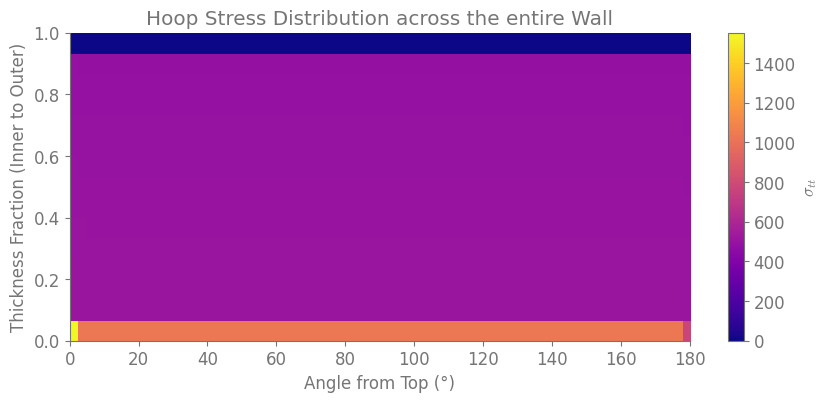

In [ ]:
# --- 1. Reshape the stress data into a grid ---
# This transforms Sig_tt from a flat array into a grid of [radial_layer, angular_index]
Sig_tt_grid = Sig_tt.reshape((n_r, n_theta))

# --- 2. Pick an angle to analyze ---
# Example: Index for the "Side" (approx 90 deg from top)
target_angle_deg = 90
# Map the angle back to the index j
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw) # From your previous code
j_target = np.argmin(np.abs(phi_in_deg_raw - target_angle_deg))

# --- 3. Extract the stress through the thickness at that angle ---
stress_slice = Sig_tt_grid[:, j_target]

# --- 4. Calculate radial distance for the X-axis of the plot ---
# Get the X and Y coordinates for this specific slice
x_slice = X.reshape((n_r, n_theta))[:, j_target]
y_slice = Y.reshape((n_r, n_theta))[:, j_target]

# Radial distance from the inner wall
dist_from_inner = np.sqrt((x_slice - x_slice[0])**2 + (y_slice - y_slice[0])**2)


plt.figure(figsize=(10, 4))
plt.imshow(Sig_tt_grid, aspect='auto', cmap='plasma', origin='lower',
           extent=[0, 180, 0, 1]) # 0 to 1 represents thickness fraction
plt.colorbar(label='$\sigma_{tt}$')
plt.xlabel('Angle from Top (°)')
plt.ylabel('Thickness Fraction (Inner to Outer)')
plt.title('Hoop Stress Distribution across the entire Wall')
plt.show()

Mesh, BCs, and Loads generated successfully.
Number of nodes: 1200
Number of elements: 2212
Number of equations: 2369
Duration for system solution: 0:00:00.907571
Duration for post processing: 0:00:00.257905
Analysis terminated successfully!


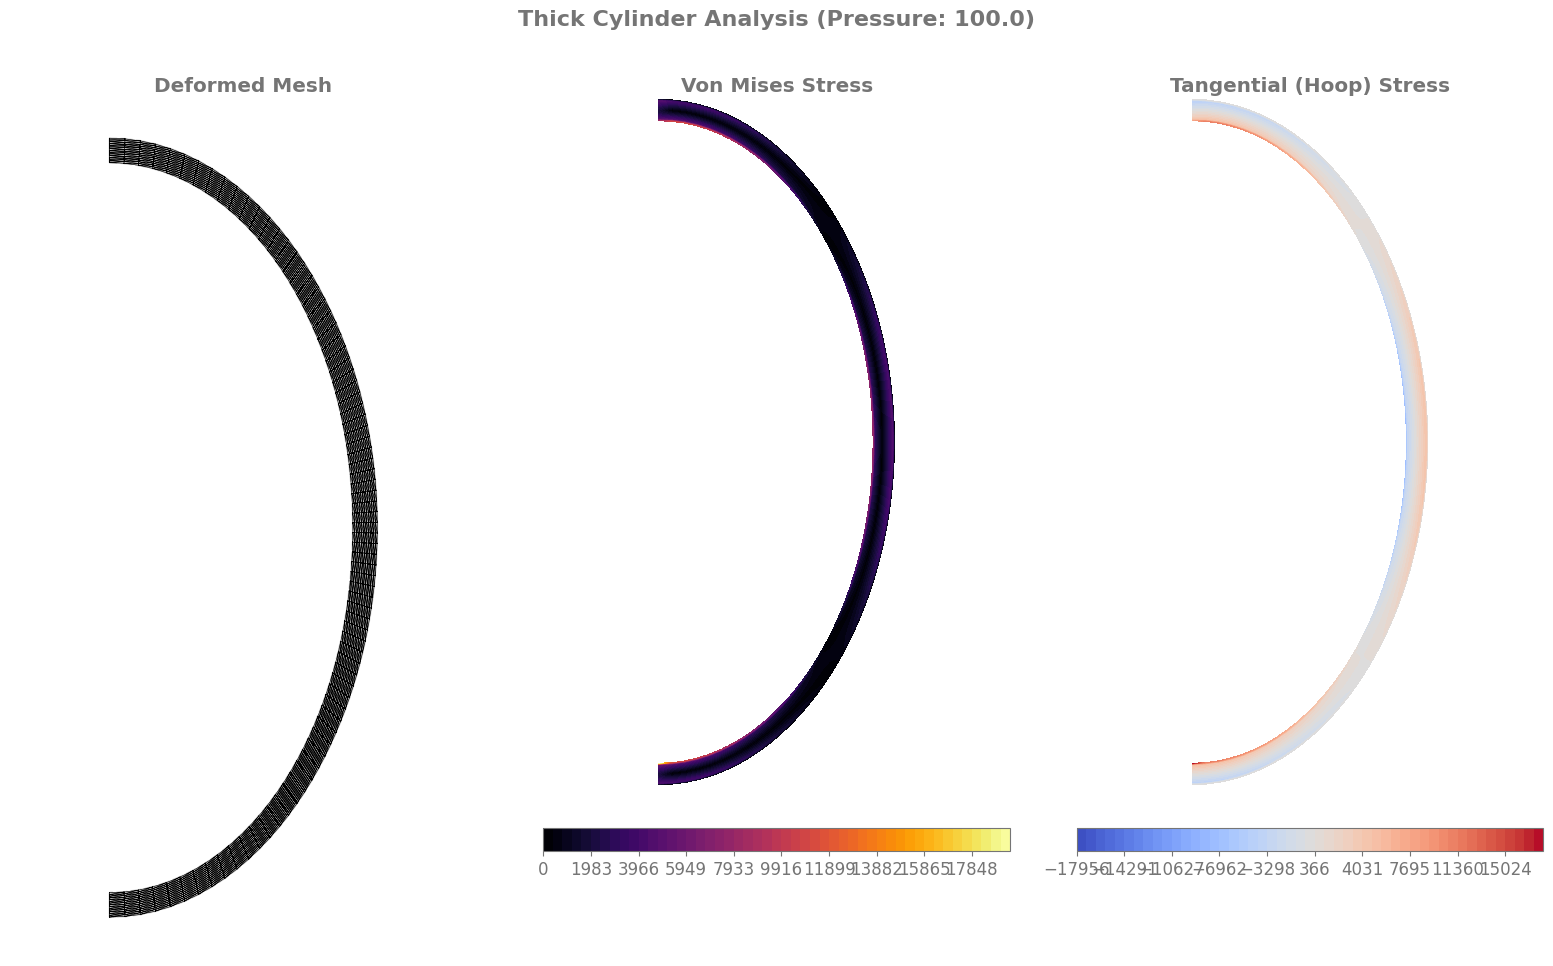

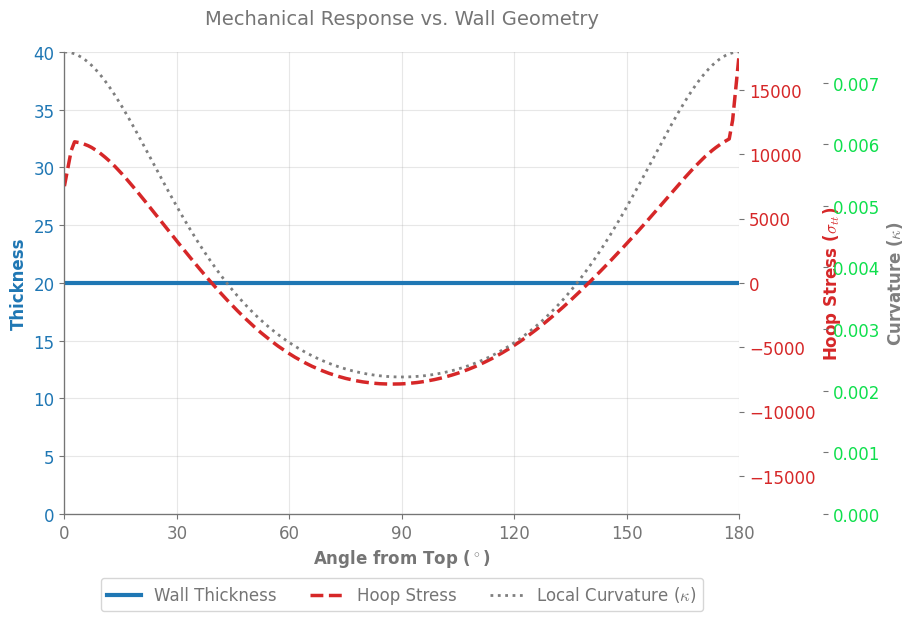

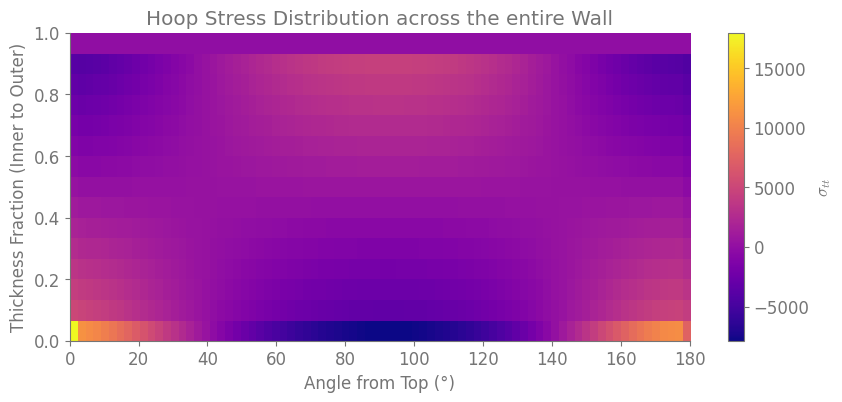

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from solidspy import solids_GUI
import solidspy.preprocesor as pre

# ==============================================================================
# 1. USER CONTROL PANEL
# ==============================================================================
# --- Geometry Parameters ---
r_i_val = 300.0*1   # Inner radius (Major axis along Y)
AR_val = 1.5   # Aspect Ratio (r_i_val / AR_val = minor axis along X)
t_top_val = 20.0*1    # Minimum thickness at top (0 deg)
t_side_val = t_top_val*1    # Maximum thickness at sides (90 deg)
t_bot_val = t_top_val*1     # Mid thickness at bottom (180 deg)

# --- Mesh Parameters ---
n_theta = 80         # Number of angular divisions (bottom to top)
n_r = 15             # Number of radial divisions (thickness)

# --- Loading ---
internal_pressure = 100.0  # Magnitude of internal pressure

# --- Material Options (Must match mater.txt) ---
# NOTE: To run this correctly as Plane Strain (thick cylinder), ensure your 
# mater.txt file uses Effective Properties: E' = E/(1-v^2), v' = v/(1-v)
# ==============================================================================

# ==============================================================================
# 2. MESH & FILE GENERATION
# ==============================================================================
def generate_and_save_model(r_i, AR, t_top, t_side, t_bot, n_t, n_r, pressure):
    """Generates half-tube mesh, BCs, and Loads, saving them for SolidSpy."""
    
    # --- A. Generate Mesh ---
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)
    
    a, b = r_i / AR, r_i
    A_t = (2*t_side + t_top + t_bot) / 4.0
    B_t = (t_top - t_bot) / 2.0
    C_t = (2*t_side - t_top - t_bot) / 4.0

    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_in = (a * b) / np.sqrt((b * np.cos(theta))**2 + (a * np.sin(theta))**2)
        t_theta = A_t + B_t * np.sin(theta) + C_t * np.cos(2*theta)
        r_out = r_in + r_frac * t_theta
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    triangles = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1, n2 = i*n_t + j, i*n_t + (j + 1)
            n3, n4 = (i + 1)*n_t + j, (i + 1)*n_t + (j + 1)
            triangles.extend([[n1, n3, n2], [n2, n3, n4]])
    triangles = np.array(triangles)

    # --- B. Save Nodes (with BCs) & Elements ---
    min_y = np.min(nodes_y)
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    with open("eles.txt", 'w') as feles:
        for i, tri in enumerate(triangles):
            feles.write(f"{i} 3 0 {tri[0]} {tri[1]} {tri[2]}\n")

    # --- C. Save Pressure Loads ---
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx = nodes_x[n2] - nodes_x[n1]
        dy = nodes_y[n2] - nodes_y[n1]
        
        # Normal pointing into the solid (dy, -dx)
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        
        F_x[n1] += 0.5 * fx_seg; F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg; F_y[n2] += 0.5 * fy_seg

    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")
                
    return nodes_x, nodes_y, triangles

# Generate files based on user inputs
X, Y, tri_elements = generate_and_save_model(
    r_i_val, AR_val, t_top_val, t_side_val, t_bot_val, n_theta, n_r, internal_pressure
)
print("Mesh, BCs, and Loads generated successfully.")


# ==============================================================================
# 3. RUN FEA (SolidSpy)
# ==============================================================================
# Ensure mater.txt exists in the working directory before running this!
disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

# Extract Results
U_x, U_y = disp[:, 0], disp[:, 1]
Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]
von_mises = np.sqrt(Sig_xx**2 - Sig_xx*Sig_yy + Sig_yy**2 + 3*Tau_xy**2)


# ==============================================================================
# 4. POST-PROCESSING (Stress Projection)
# ==============================================================================
# Calculate Tangential (Hoop) Stress based on local geometry
theta_all = np.arctan2(Y, X)
theta_in_raw = np.arctan2(Y[:n_theta], X[:n_theta])
sort_idx = np.argsort(theta_in_raw)

x_in, y_in = X[:n_theta][sort_idx], Y[:n_theta][sort_idx]
theta_in_sorted = theta_in_raw[sort_idx]

# Tangent/Normal calculation
dx_in, dy_in = np.gradient(x_in), np.gradient(y_in)
alpha_inner = np.arctan2(dy_in, dx_in) - (np.pi / 2.0)

# Map normal angle to all nodes
closest_idx = np.argmin(np.abs(theta_all[:, np.newaxis] - theta_in_sorted), axis=1)
alpha_all = alpha_inner[closest_idx]
c, s = np.cos(alpha_all), np.sin(alpha_all)

# Project Stress
Sig_tt = Sig_xx * s**2 + Sig_yy * c**2 - 2 * Tau_xy * s * c


# ==============================================================================
# 5. VISUALIZATION (Consolidated Subplots)
# ==============================================================================
fig = plt.figure(figsize=(16, 10))

# --- Subplot 1: Geometry & Deformation ---
ax1 = plt.subplot(1, 3, 1)
scale = 1  # Deformation scale factor
ax1.triplot(X, Y, tri_elements, color='gray', linestyle='--', alpha=0.3)
ax1.triplot(X + U_x*scale, Y + U_y*scale, tri_elements, color='black', lw=0.5)
ax1.set_title("Deformed Mesh", fontweight='bold')
ax1.axis('equal'); ax1.axis('off')


# --- Subplot 2: Von Mises Stress ---
ax2 = plt.subplot(1, 3, 2)
levels_vm = np.linspace(0, np.max(von_mises), 50)
cont2 = ax2.tricontourf(X, Y, tri_elements, von_mises, levels=levels_vm, cmap='inferno')
ax2.set_title("Von Mises Stress", fontweight='bold')
ax2.axis('equal'); ax2.axis('off')
fig.colorbar(cont2, ax=ax2, orientation='horizontal', pad=0.05)

# --- Subplot 3: Tangential (Hoop) Stress ---
ax3 = plt.subplot(1, 3, 3)
max_tt = np.max(np.abs(Sig_tt))
levels_tt = np.linspace(-max_tt, max_tt, 50)
cont3 = ax3.tricontourf(X, Y, tri_elements, Sig_tt, levels=levels_tt, cmap='coolwarm')
ax3.set_title("Tangential (Hoop) Stress", fontweight='bold')
ax3.axis('equal'); ax3.axis('off')
fig.colorbar(cont3, ax=ax3, orientation='horizontal', pad=0.05)

plt.suptitle(f"Thick Cylinder Analysis (Pressure: {internal_pressure})", fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()
# ==============================================================================
# 6. GEOMETRY (THICKNESS & CURVATURE) vs STRESS CORRELATION
# ==============================================================================
phi_deg = np.linspace(0, 180, 200)
theta_math = np.pi/2 - np.deg2rad(phi_deg) # Top is pi/2, Side is 0, Bottom is -pi/2

# --- 1. Extract Stress Data ---
sig_tt_in_raw = Sig_tt[:n_theta]
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw)
sort_idx2 = np.argsort(phi_in_deg_raw)
sig_tt_smooth = np.interp(phi_deg, phi_in_deg_raw[sort_idx2], sig_tt_in_raw[sort_idx2])

# --- 2. Geometry Profiles ---
# A. Thickness
A_t = (2*t_side_val + t_top_val + t_bot_val) / 4.0
B_t = (t_top_val - t_bot_val) / 2.0
C_t = (2*t_side_val - t_top_val - t_bot_val) / 4.0
thickness = A_t + B_t * np.sin(theta_math) + C_t * np.cos(2*theta_math)

# B. Local Curvature (Kappa)
a = r_i_val / AR_val  # Semi-minor axis (X)
b = r_i_val           # Semi-major axis (Y)
numerator = a * b
denominator = (a**2 * np.sin(theta_math)**2 + b**2 * np.cos(theta_math)**2)**(1.5)
kappa = numerator / denominator

# --- 3. Plotting with Triple Y-Axes ---
fig2, ax_t = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.8) # Make room for the third axis

ax_s = ax_t.twinx() # Second axis for Stress
ax_k = ax_t.twinx() # Third axis for Curvature

# Offset the third axis (Curvature) to the right
ax_k.spines['right'].set_position(('outward', 60))

# Plot lines
line1 = ax_t.plot(phi_deg, thickness, color='#1f77b4', lw=3, label='Wall Thickness')
line2 = ax_s.plot(phi_deg, sig_tt_smooth, color='#d62728', lw=2.5, ls='--', label='Hoop Stress')
line3 = ax_k.plot(phi_deg, kappa, color='#7f7f7f', lw=2, ls=':', label='Local Curvature ($\kappa$)')

# Labeling
ax_t.set_xlabel('Angle from Top ($^\circ$)', fontweight='bold')
ax_t.set_ylabel('Thickness', color='#1f77b4', fontweight='bold')
ax_s.set_ylabel('Hoop Stress ($\sigma_{tt}$)', color='#d62728', fontweight='bold')
ax_k.set_ylabel('Curvature ($\kappa$)', color='#7f7f7f', fontweight='bold')

# Colors and Ticks
ax_t.tick_params(axis='y', labelcolor='#1f77b4')
ax_s.tick_params(axis='y', labelcolor='#d62728')
ax_k.tick_params(axis='y', labelcolor="#0fdf4d")

ax_t.set_xlim(0, 180)
ax_t.set_ylim(0, np.max(thickness)*2)
ax_t.set_xticks(np.arange(0, 181, 30))
ax_t.grid(True, alpha=0.3)

ax_k.set_ylim(0, np.max(kappa))
ax_s.set_ylim(-np.max(sig_tt_smooth), np.max(sig_tt_smooth))

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_t.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('Mechanical Response vs. Wall Geometry', fontsize=14, pad=20)
plt.show()

# --- 1. Reshape the stress data into a grid ---
# This transforms Sig_tt from a flat array into a grid of [radial_layer, angular_index]
Sig_tt_grid = Sig_tt.reshape((n_r, n_theta))

# --- 2. Pick an angle to analyze ---
# Example: Index for the "Side" (approx 90 deg from top)
target_angle_deg = 90
# Map the angle back to the index j
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw) # From your previous code
j_target = np.argmin(np.abs(phi_in_deg_raw - target_angle_deg))

# --- 3. Extract the stress through the thickness at that angle ---
stress_slice = Sig_tt_grid[:, j_target]

# --- 4. Calculate radial distance for the X-axis of the plot ---
# Get the X and Y coordinates for this specific slice
x_slice = X.reshape((n_r, n_theta))[:, j_target]
y_slice = Y.reshape((n_r, n_theta))[:, j_target]

# Radial distance from the inner wall
dist_from_inner = np.sqrt((x_slice - x_slice[0])**2 + (y_slice - y_slice[0])**2)


plt.figure(figsize=(10, 4))
plt.imshow(Sig_tt_grid, aspect='auto', cmap='plasma', origin='lower',
           extent=[0, 180, 0, 1]) # 0 to 1 represents thickness fraction
plt.colorbar(label='$\sigma_{tt}$')
plt.xlabel('Angle from Top (°)')
plt.ylabel('Thickness Fraction (Inner to Outer)')
plt.title('Hoop Stress Distribution across the entire Wall')
plt.show()

Mesh, BCs, and Loads generated successfully.
Number of nodes: 1200
Number of elements: 2212
Number of equations: 2369
Duration for system solution: 0:00:00.866840
Duration for post processing: 0:00:00.268980
Analysis terminated successfully!


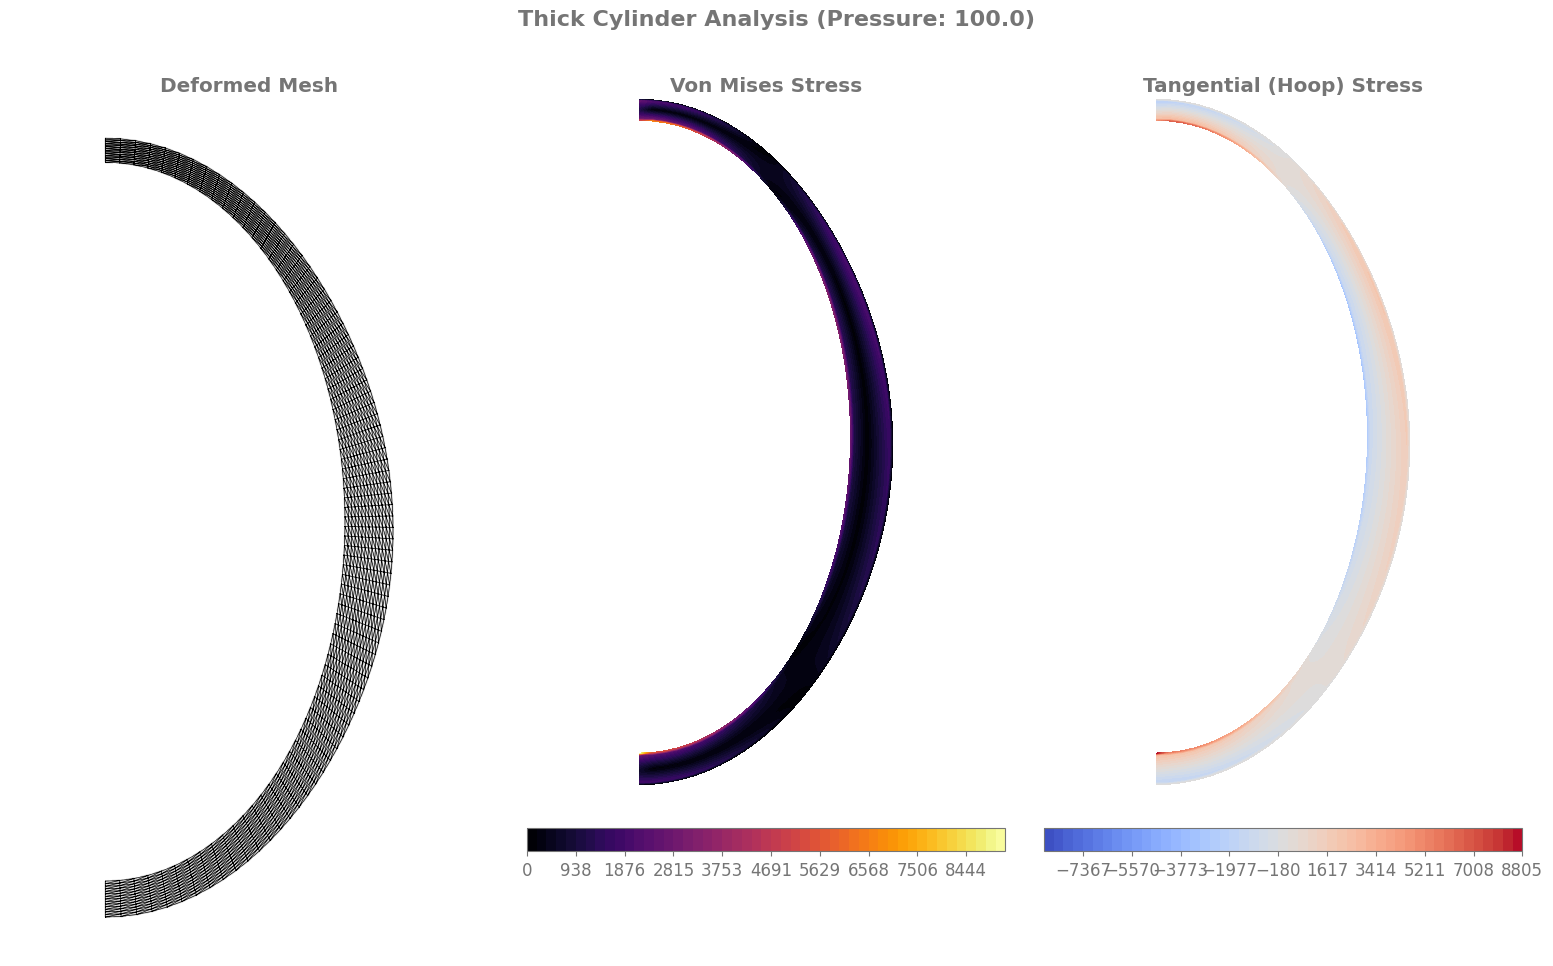

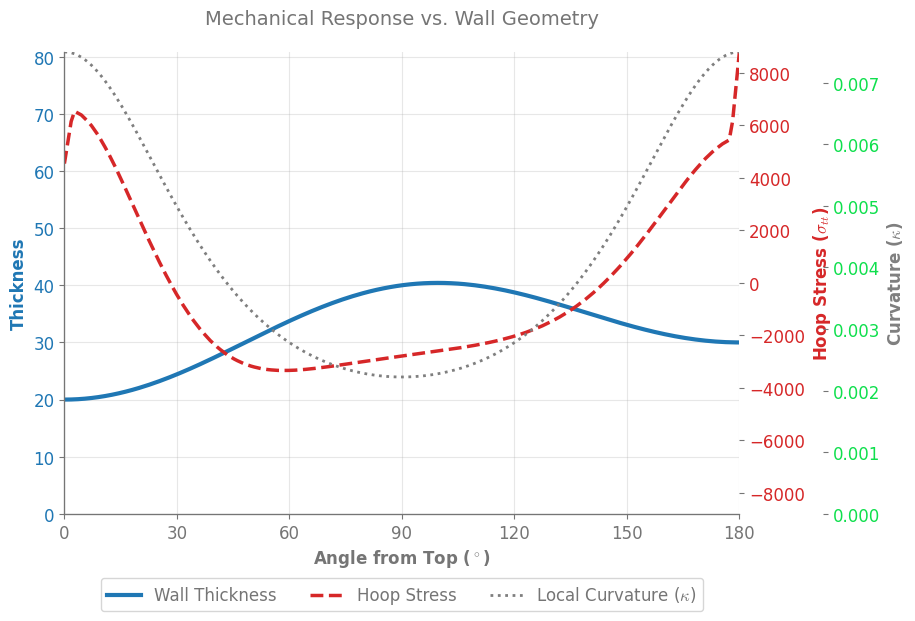

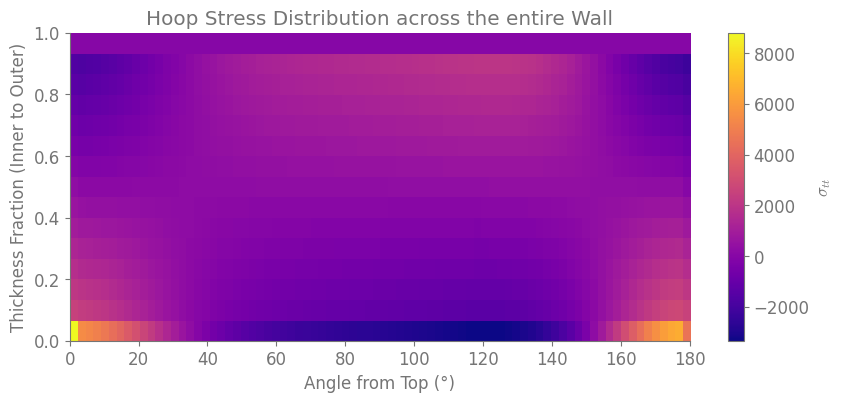

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from solidspy import solids_GUI
import solidspy.preprocesor as pre

# ==============================================================================
# 1. USER CONTROL PANEL
# ==============================================================================
# --- Geometry Parameters ---
r_i_val = 300.0*1   # Inner radius (Major axis along Y)
AR_val = 1.5   # Aspect Ratio (r_i_val / AR_val = minor axis along X)
t_top_val = 20.0*1    # Minimum thickness at top (0 deg)
t_side_val = t_top_val*2    # Maximum thickness at sides (90 deg)
t_bot_val = t_top_val*1.5     # Mid thickness at bottom (180 deg)

# --- Mesh Parameters ---
n_theta = 80         # Number of angular divisions (bottom to top)
n_r = 15             # Number of radial divisions (thickness)

# --- Loading ---
internal_pressure = 100.0  # Magnitude of internal pressure

# --- Material Options (Must match mater.txt) ---
# NOTE: To run this correctly as Plane Strain (thick cylinder), ensure your 
# mater.txt file uses Effective Properties: E' = E/(1-v^2), v' = v/(1-v)
# ==============================================================================

# ==============================================================================
# 2. MESH & FILE GENERATION
# ==============================================================================
def generate_and_save_model(r_i, AR, t_top, t_side, t_bot, n_t, n_r, pressure):
    """Generates half-tube mesh, BCs, and Loads, saving them for SolidSpy."""
    
    # --- A. Generate Mesh ---
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)
    
    a, b = r_i / AR, r_i
    A_t = (2*t_side + t_top + t_bot) / 4.0
    B_t = (t_top - t_bot) / 2.0
    C_t = (2*t_side - t_top - t_bot) / 4.0

    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_in = (a * b) / np.sqrt((b * np.cos(theta))**2 + (a * np.sin(theta))**2)
        t_theta = A_t + B_t * np.sin(theta) + C_t * np.cos(2*theta)
        r_out = r_in + r_frac * t_theta
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    triangles = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1, n2 = i*n_t + j, i*n_t + (j + 1)
            n3, n4 = (i + 1)*n_t + j, (i + 1)*n_t + (j + 1)
            triangles.extend([[n1, n3, n2], [n2, n3, n4]])
    triangles = np.array(triangles)

    # --- B. Save Nodes (with BCs) & Elements ---
    min_y = np.min(nodes_y)
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    with open("eles.txt", 'w') as feles:
        for i, tri in enumerate(triangles):
            feles.write(f"{i} 3 0 {tri[0]} {tri[1]} {tri[2]}\n")

    # --- C. Save Pressure Loads ---
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx = nodes_x[n2] - nodes_x[n1]
        dy = nodes_y[n2] - nodes_y[n1]
        
        # Normal pointing into the solid (dy, -dx)
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        
        F_x[n1] += 0.5 * fx_seg; F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg; F_y[n2] += 0.5 * fy_seg

    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")
                
    return nodes_x, nodes_y, triangles

# Generate files based on user inputs
X, Y, tri_elements = generate_and_save_model(
    r_i_val, AR_val, t_top_val, t_side_val, t_bot_val, n_theta, n_r, internal_pressure
)
print("Mesh, BCs, and Loads generated successfully.")


# ==============================================================================
# 3. RUN FEA (SolidSpy)
# ==============================================================================
# Ensure mater.txt exists in the working directory before running this!
disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

# Extract Results
U_x, U_y = disp[:, 0], disp[:, 1]
Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]
von_mises = np.sqrt(Sig_xx**2 - Sig_xx*Sig_yy + Sig_yy**2 + 3*Tau_xy**2)


# ==============================================================================
# 4. POST-PROCESSING (Stress Projection)
# ==============================================================================
# Calculate Tangential (Hoop) Stress based on local geometry
theta_all = np.arctan2(Y, X)
theta_in_raw = np.arctan2(Y[:n_theta], X[:n_theta])
sort_idx = np.argsort(theta_in_raw)

x_in, y_in = X[:n_theta][sort_idx], Y[:n_theta][sort_idx]
theta_in_sorted = theta_in_raw[sort_idx]

# Tangent/Normal calculation
dx_in, dy_in = np.gradient(x_in), np.gradient(y_in)
alpha_inner = np.arctan2(dy_in, dx_in) - (np.pi / 2.0)

# Map normal angle to all nodes
closest_idx = np.argmin(np.abs(theta_all[:, np.newaxis] - theta_in_sorted), axis=1)
alpha_all = alpha_inner[closest_idx]
c, s = np.cos(alpha_all), np.sin(alpha_all)

# Project Stress
Sig_tt = Sig_xx * s**2 + Sig_yy * c**2 - 2 * Tau_xy * s * c


# ==============================================================================
# 5. VISUALIZATION (Consolidated Subplots)
# ==============================================================================
fig = plt.figure(figsize=(16, 10))

# --- Subplot 1: Geometry & Deformation ---
ax1 = plt.subplot(1, 3, 1)
scale = 1  # Deformation scale factor
ax1.triplot(X, Y, tri_elements, color='gray', linestyle='--', alpha=0.3)
ax1.triplot(X + U_x*scale, Y + U_y*scale, tri_elements, color='black', lw=0.5)
ax1.set_title("Deformed Mesh", fontweight='bold')
ax1.axis('equal'); ax1.axis('off')


# --- Subplot 2: Von Mises Stress ---
ax2 = plt.subplot(1, 3, 2)
levels_vm = np.linspace(0, np.max(von_mises), 50)
cont2 = ax2.tricontourf(X, Y, tri_elements, von_mises, levels=levels_vm, cmap='inferno')
ax2.set_title("Von Mises Stress", fontweight='bold')
ax2.axis('equal'); ax2.axis('off')
fig.colorbar(cont2, ax=ax2, orientation='horizontal', pad=0.05)

# --- Subplot 3: Tangential (Hoop) Stress ---
ax3 = plt.subplot(1, 3, 3)
max_tt = np.max(np.abs(Sig_tt))
levels_tt = np.linspace(-max_tt, max_tt, 50)
cont3 = ax3.tricontourf(X, Y, tri_elements, Sig_tt, levels=levels_tt, cmap='coolwarm')
ax3.set_title("Tangential (Hoop) Stress", fontweight='bold')
ax3.axis('equal'); ax3.axis('off')
fig.colorbar(cont3, ax=ax3, orientation='horizontal', pad=0.05)

plt.suptitle(f"Thick Cylinder Analysis (Pressure: {internal_pressure})", fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()
# ==============================================================================
# 6. GEOMETRY (THICKNESS & CURVATURE) vs STRESS CORRELATION
# ==============================================================================
phi_deg = np.linspace(0, 180, 200)
theta_math = np.pi/2 - np.deg2rad(phi_deg) # Top is pi/2, Side is 0, Bottom is -pi/2

# --- 1. Extract Stress Data ---
sig_tt_in_raw = Sig_tt[:n_theta]
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw)
sort_idx2 = np.argsort(phi_in_deg_raw)
sig_tt_smooth = np.interp(phi_deg, phi_in_deg_raw[sort_idx2], sig_tt_in_raw[sort_idx2])

# --- 2. Geometry Profiles ---
# A. Thickness
A_t = (2*t_side_val + t_top_val + t_bot_val) / 4.0
B_t = (t_top_val - t_bot_val) / 2.0
C_t = (2*t_side_val - t_top_val - t_bot_val) / 4.0
thickness = A_t + B_t * np.sin(theta_math) + C_t * np.cos(2*theta_math)

# B. Local Curvature (Kappa)
a = r_i_val / AR_val  # Semi-minor axis (X)
b = r_i_val           # Semi-major axis (Y)
numerator = a * b
denominator = (a**2 * np.sin(theta_math)**2 + b**2 * np.cos(theta_math)**2)**(1.5)
kappa = numerator / denominator

# --- 3. Plotting with Triple Y-Axes ---
fig2, ax_t = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.8) # Make room for the third axis

ax_s = ax_t.twinx() # Second axis for Stress
ax_k = ax_t.twinx() # Third axis for Curvature

# Offset the third axis (Curvature) to the right
ax_k.spines['right'].set_position(('outward', 60))

# Plot lines
line1 = ax_t.plot(phi_deg, thickness, color='#1f77b4', lw=3, label='Wall Thickness')
line2 = ax_s.plot(phi_deg, sig_tt_smooth, color='#d62728', lw=2.5, ls='--', label='Hoop Stress')
line3 = ax_k.plot(phi_deg, kappa, color='#7f7f7f', lw=2, ls=':', label='Local Curvature ($\kappa$)')

# Labeling
ax_t.set_xlabel('Angle from Top ($^\circ$)', fontweight='bold')
ax_t.set_ylabel('Thickness', color='#1f77b4', fontweight='bold')
ax_s.set_ylabel('Hoop Stress ($\sigma_{tt}$)', color='#d62728', fontweight='bold')
ax_k.set_ylabel('Curvature ($\kappa$)', color='#7f7f7f', fontweight='bold')

# Colors and Ticks
ax_t.tick_params(axis='y', labelcolor='#1f77b4')
ax_s.tick_params(axis='y', labelcolor='#d62728')
ax_k.tick_params(axis='y', labelcolor="#0fdf4d")

ax_t.set_xlim(0, 180)
ax_t.set_ylim(0, np.max(thickness)*2)
ax_t.set_xticks(np.arange(0, 181, 30))
ax_t.grid(True, alpha=0.3)

ax_k.set_ylim(0, np.max(kappa))
ax_s.set_ylim(-np.max(sig_tt_smooth), np.max(sig_tt_smooth))

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_t.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('Mechanical Response vs. Wall Geometry', fontsize=14, pad=20)
plt.show()

# --- 1. Reshape the stress data into a grid ---
# This transforms Sig_tt from a flat array into a grid of [radial_layer, angular_index]
Sig_tt_grid = Sig_tt.reshape((n_r, n_theta))

# --- 2. Pick an angle to analyze ---
# Example: Index for the "Side" (approx 90 deg from top)
target_angle_deg = 90
# Map the angle back to the index j
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw) # From your previous code
j_target = np.argmin(np.abs(phi_in_deg_raw - target_angle_deg))

# --- 3. Extract the stress through the thickness at that angle ---
stress_slice = Sig_tt_grid[:, j_target]

# --- 4. Calculate radial distance for the X-axis of the plot ---
# Get the X and Y coordinates for this specific slice
x_slice = X.reshape((n_r, n_theta))[:, j_target]
y_slice = Y.reshape((n_r, n_theta))[:, j_target]

# Radial distance from the inner wall
dist_from_inner = np.sqrt((x_slice - x_slice[0])**2 + (y_slice - y_slice[0])**2)


plt.figure(figsize=(10, 4))
plt.imshow(Sig_tt_grid, aspect='auto', cmap='plasma', origin='lower',
           extent=[0, 180, 0, 1]) # 0 to 1 represents thickness fraction
plt.colorbar(label='$\sigma_{tt}$')
plt.xlabel('Angle from Top (°)')
plt.ylabel('Thickness Fraction (Inner to Outer)')
plt.title('Hoop Stress Distribution across the entire Wall')
plt.show()

Mesh, BCs, and Loads generated successfully.
Number of nodes: 1200
Number of elements: 2212
Number of equations: 2369
Duration for system solution: 0:00:00.927567
Duration for post processing: 0:00:00.318349
Analysis terminated successfully!


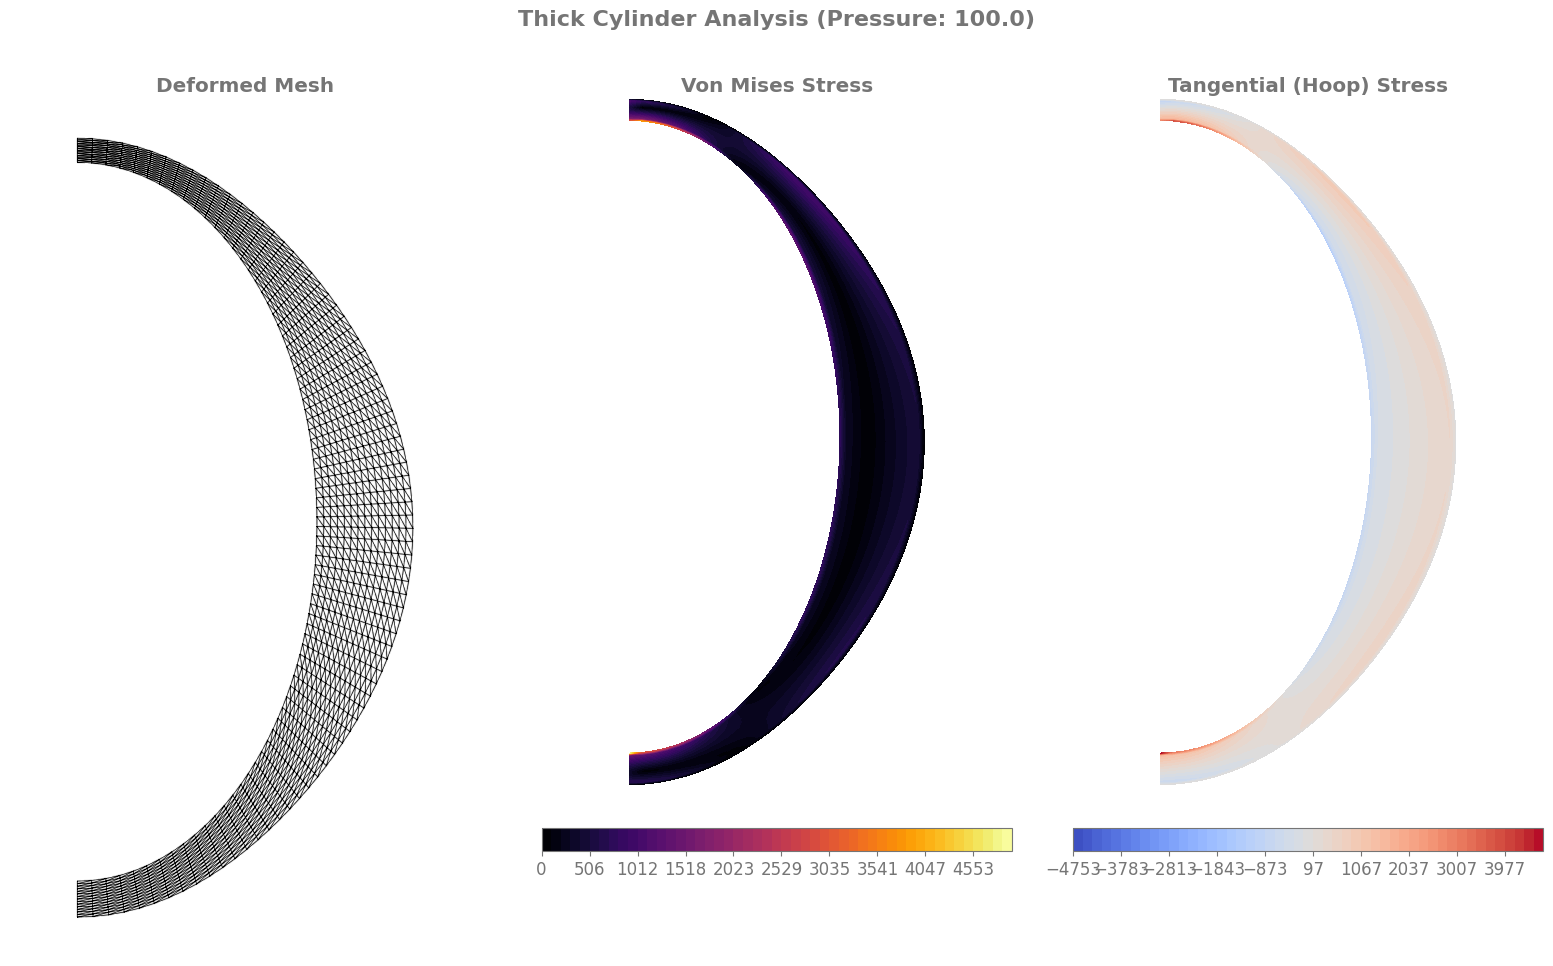

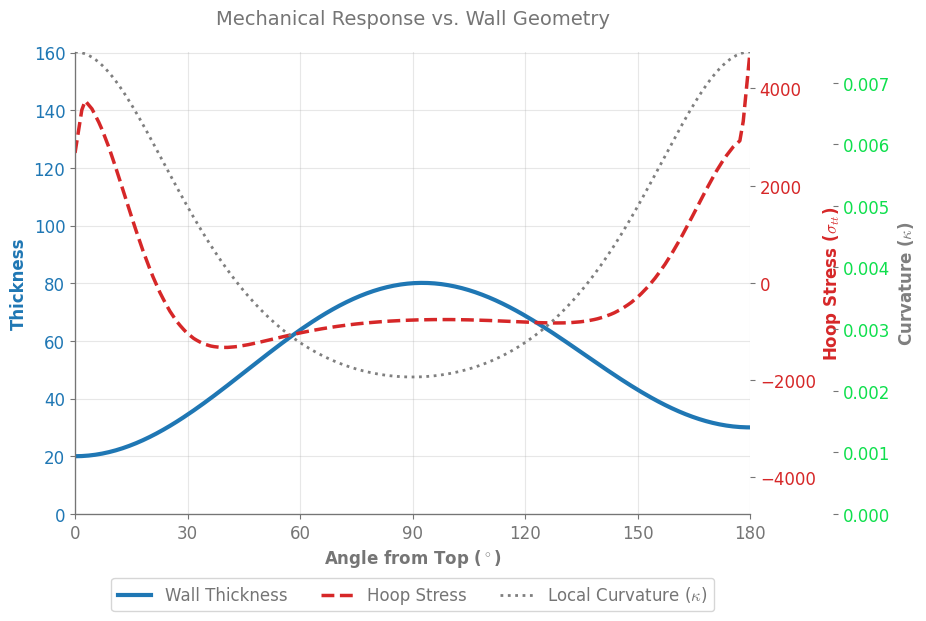

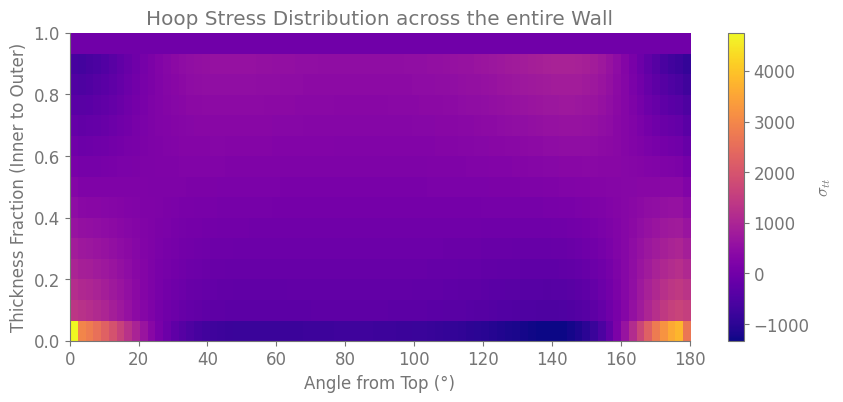

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from solidspy import solids_GUI
import solidspy.preprocesor as pre

# ==============================================================================
# 1. USER CONTROL PANEL
# ==============================================================================
# --- Geometry Parameters ---
r_i_val = 300.0*1   # Inner radius (Major axis along Y)
AR_val = 1.5   # Aspect Ratio (r_i_val / AR_val = minor axis along X)
t_top_val = 20.0*1    # Minimum thickness at top (0 deg)
t_side_val = t_top_val*4    # Maximum thickness at sides (90 deg)
t_bot_val = t_top_val*1.5     # Mid thickness at bottom (180 deg)

# --- Mesh Parameters ---
n_theta = 80         # Number of angular divisions (bottom to top)
n_r = 15             # Number of radial divisions (thickness)

# --- Loading ---
internal_pressure = 100.0  # Magnitude of internal pressure

# --- Material Options (Must match mater.txt) ---
# NOTE: To run this correctly as Plane Strain (thick cylinder), ensure your 
# mater.txt file uses Effective Properties: E' = E/(1-v^2), v' = v/(1-v)
# ==============================================================================

# ==============================================================================
# 2. MESH & FILE GENERATION
# ==============================================================================
def generate_and_save_model(r_i, AR, t_top, t_side, t_bot, n_t, n_r, pressure):
    """Generates half-tube mesh, BCs, and Loads, saving them for SolidSpy."""
    
    # --- A. Generate Mesh ---
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)
    
    a, b = r_i / AR, r_i
    A_t = (2*t_side + t_top + t_bot) / 4.0
    B_t = (t_top - t_bot) / 2.0
    C_t = (2*t_side - t_top - t_bot) / 4.0

    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_in = (a * b) / np.sqrt((b * np.cos(theta))**2 + (a * np.sin(theta))**2)
        t_theta = A_t + B_t * np.sin(theta) + C_t * np.cos(2*theta)
        r_out = r_in + r_frac * t_theta
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    triangles = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1, n2 = i*n_t + j, i*n_t + (j + 1)
            n3, n4 = (i + 1)*n_t + j, (i + 1)*n_t + (j + 1)
            triangles.extend([[n1, n3, n2], [n2, n3, n4]])
    triangles = np.array(triangles)

    # --- B. Save Nodes (with BCs) & Elements ---
    min_y = np.min(nodes_y)
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    with open("eles.txt", 'w') as feles:
        for i, tri in enumerate(triangles):
            feles.write(f"{i} 3 0 {tri[0]} {tri[1]} {tri[2]}\n")

    # --- C. Save Pressure Loads ---
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx = nodes_x[n2] - nodes_x[n1]
        dy = nodes_y[n2] - nodes_y[n1]
        
        # Normal pointing into the solid (dy, -dx)
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        
        F_x[n1] += 0.5 * fx_seg; F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg; F_y[n2] += 0.5 * fy_seg

    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")
                
    return nodes_x, nodes_y, triangles

# Generate files based on user inputs
X, Y, tri_elements = generate_and_save_model(
    r_i_val, AR_val, t_top_val, t_side_val, t_bot_val, n_theta, n_r, internal_pressure
)
print("Mesh, BCs, and Loads generated successfully.")


# ==============================================================================
# 3. RUN FEA (SolidSpy)
# ==============================================================================
# Ensure mater.txt exists in the working directory before running this!
disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

# Extract Results
U_x, U_y = disp[:, 0], disp[:, 1]
Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]
von_mises = np.sqrt(Sig_xx**2 - Sig_xx*Sig_yy + Sig_yy**2 + 3*Tau_xy**2)


# ==============================================================================
# 4. POST-PROCESSING (Stress Projection)
# ==============================================================================
# Calculate Tangential (Hoop) Stress based on local geometry
theta_all = np.arctan2(Y, X)
theta_in_raw = np.arctan2(Y[:n_theta], X[:n_theta])
sort_idx = np.argsort(theta_in_raw)

x_in, y_in = X[:n_theta][sort_idx], Y[:n_theta][sort_idx]
theta_in_sorted = theta_in_raw[sort_idx]

# Tangent/Normal calculation
dx_in, dy_in = np.gradient(x_in), np.gradient(y_in)
alpha_inner = np.arctan2(dy_in, dx_in) - (np.pi / 2.0)

# Map normal angle to all nodes
closest_idx = np.argmin(np.abs(theta_all[:, np.newaxis] - theta_in_sorted), axis=1)
alpha_all = alpha_inner[closest_idx]
c, s = np.cos(alpha_all), np.sin(alpha_all)

# Project Stress
Sig_tt = Sig_xx * s**2 + Sig_yy * c**2 - 2 * Tau_xy * s * c


# ==============================================================================
# 5. VISUALIZATION (Consolidated Subplots)
# ==============================================================================
fig = plt.figure(figsize=(16, 10))

# --- Subplot 1: Geometry & Deformation ---
ax1 = plt.subplot(1, 3, 1)
scale = 1  # Deformation scale factor
ax1.triplot(X, Y, tri_elements, color='gray', linestyle='--', alpha=0.3)
ax1.triplot(X + U_x*scale, Y + U_y*scale, tri_elements, color='black', lw=0.5)
ax1.set_title("Deformed Mesh", fontweight='bold')
ax1.axis('equal'); ax1.axis('off')


# --- Subplot 2: Von Mises Stress ---
ax2 = plt.subplot(1, 3, 2)
levels_vm = np.linspace(0, np.max(von_mises), 50)
cont2 = ax2.tricontourf(X, Y, tri_elements, von_mises, levels=levels_vm, cmap='inferno')
ax2.set_title("Von Mises Stress", fontweight='bold')
ax2.axis('equal'); ax2.axis('off')
fig.colorbar(cont2, ax=ax2, orientation='horizontal', pad=0.05)

# --- Subplot 3: Tangential (Hoop) Stress ---
ax3 = plt.subplot(1, 3, 3)
max_tt = np.max(np.abs(Sig_tt))
levels_tt = np.linspace(-max_tt, max_tt, 50)
cont3 = ax3.tricontourf(X, Y, tri_elements, Sig_tt, levels=levels_tt, cmap='coolwarm')
ax3.set_title("Tangential (Hoop) Stress", fontweight='bold')
ax3.axis('equal'); ax3.axis('off')
fig.colorbar(cont3, ax=ax3, orientation='horizontal', pad=0.05)

plt.suptitle(f"Thick Cylinder Analysis (Pressure: {internal_pressure})", fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()
# ==============================================================================
# 6. GEOMETRY (THICKNESS & CURVATURE) vs STRESS CORRELATION
# ==============================================================================
phi_deg = np.linspace(0, 180, 200)
theta_math = np.pi/2 - np.deg2rad(phi_deg) # Top is pi/2, Side is 0, Bottom is -pi/2

# --- 1. Extract Stress Data ---
sig_tt_in_raw = Sig_tt[:n_theta]
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw)
sort_idx2 = np.argsort(phi_in_deg_raw)
sig_tt_smooth = np.interp(phi_deg, phi_in_deg_raw[sort_idx2], sig_tt_in_raw[sort_idx2])

# --- 2. Geometry Profiles ---
# A. Thickness
A_t = (2*t_side_val + t_top_val + t_bot_val) / 4.0
B_t = (t_top_val - t_bot_val) / 2.0
C_t = (2*t_side_val - t_top_val - t_bot_val) / 4.0
thickness = A_t + B_t * np.sin(theta_math) + C_t * np.cos(2*theta_math)

# B. Local Curvature (Kappa)
a = r_i_val / AR_val  # Semi-minor axis (X)
b = r_i_val           # Semi-major axis (Y)
numerator = a * b
denominator = (a**2 * np.sin(theta_math)**2 + b**2 * np.cos(theta_math)**2)**(1.5)
kappa = numerator / denominator

# --- 3. Plotting with Triple Y-Axes ---
fig2, ax_t = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.8) # Make room for the third axis

ax_s = ax_t.twinx() # Second axis for Stress
ax_k = ax_t.twinx() # Third axis for Curvature

# Offset the third axis (Curvature) to the right
ax_k.spines['right'].set_position(('outward', 60))

# Plot lines
line1 = ax_t.plot(phi_deg, thickness, color='#1f77b4', lw=3, label='Wall Thickness')
line2 = ax_s.plot(phi_deg, sig_tt_smooth, color='#d62728', lw=2.5, ls='--', label='Hoop Stress')
line3 = ax_k.plot(phi_deg, kappa, color='#7f7f7f', lw=2, ls=':', label='Local Curvature ($\kappa$)')

# Labeling
ax_t.set_xlabel('Angle from Top ($^\circ$)', fontweight='bold')
ax_t.set_ylabel('Thickness', color='#1f77b4', fontweight='bold')
ax_s.set_ylabel('Hoop Stress ($\sigma_{tt}$)', color='#d62728', fontweight='bold')
ax_k.set_ylabel('Curvature ($\kappa$)', color='#7f7f7f', fontweight='bold')

# Colors and Ticks
ax_t.tick_params(axis='y', labelcolor='#1f77b4')
ax_s.tick_params(axis='y', labelcolor='#d62728')
ax_k.tick_params(axis='y', labelcolor="#0fdf4d")

ax_t.set_xlim(0, 180)
ax_t.set_ylim(0, np.max(thickness)*2)
ax_t.set_xticks(np.arange(0, 181, 30))
ax_t.grid(True, alpha=0.3)

ax_k.set_ylim(0, np.max(kappa))
ax_s.set_ylim(-np.max(sig_tt_smooth), np.max(sig_tt_smooth))

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_t.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('Mechanical Response vs. Wall Geometry', fontsize=14, pad=20)
plt.show()

# --- 1. Reshape the stress data into a grid ---
# This transforms Sig_tt from a flat array into a grid of [radial_layer, angular_index]
Sig_tt_grid = Sig_tt.reshape((n_r, n_theta))

# --- 2. Pick an angle to analyze ---
# Example: Index for the "Side" (approx 90 deg from top)
target_angle_deg = 90
# Map the angle back to the index j
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw) # From your previous code
j_target = np.argmin(np.abs(phi_in_deg_raw - target_angle_deg))

# --- 3. Extract the stress through the thickness at that angle ---
stress_slice = Sig_tt_grid[:, j_target]

# --- 4. Calculate radial distance for the X-axis of the plot ---
# Get the X and Y coordinates for this specific slice
x_slice = X.reshape((n_r, n_theta))[:, j_target]
y_slice = Y.reshape((n_r, n_theta))[:, j_target]

# Radial distance from the inner wall
dist_from_inner = np.sqrt((x_slice - x_slice[0])**2 + (y_slice - y_slice[0])**2)


plt.figure(figsize=(10, 4))
plt.imshow(Sig_tt_grid, aspect='auto', cmap='plasma', origin='lower',
           extent=[0, 180, 0, 1]) # 0 to 1 represents thickness fraction
plt.colorbar(label='$\sigma_{tt}$')
plt.xlabel('Angle from Top (°)')
plt.ylabel('Thickness Fraction (Inner to Outer)')
plt.title('Hoop Stress Distribution across the entire Wall')
plt.show()

Mesh, BCs, and Loads generated successfully.
Number of nodes: 1200
Number of elements: 2212
Number of equations: 2369
Duration for system solution: 0:00:00.973150
Duration for post processing: 0:00:00.397547
Analysis terminated successfully!


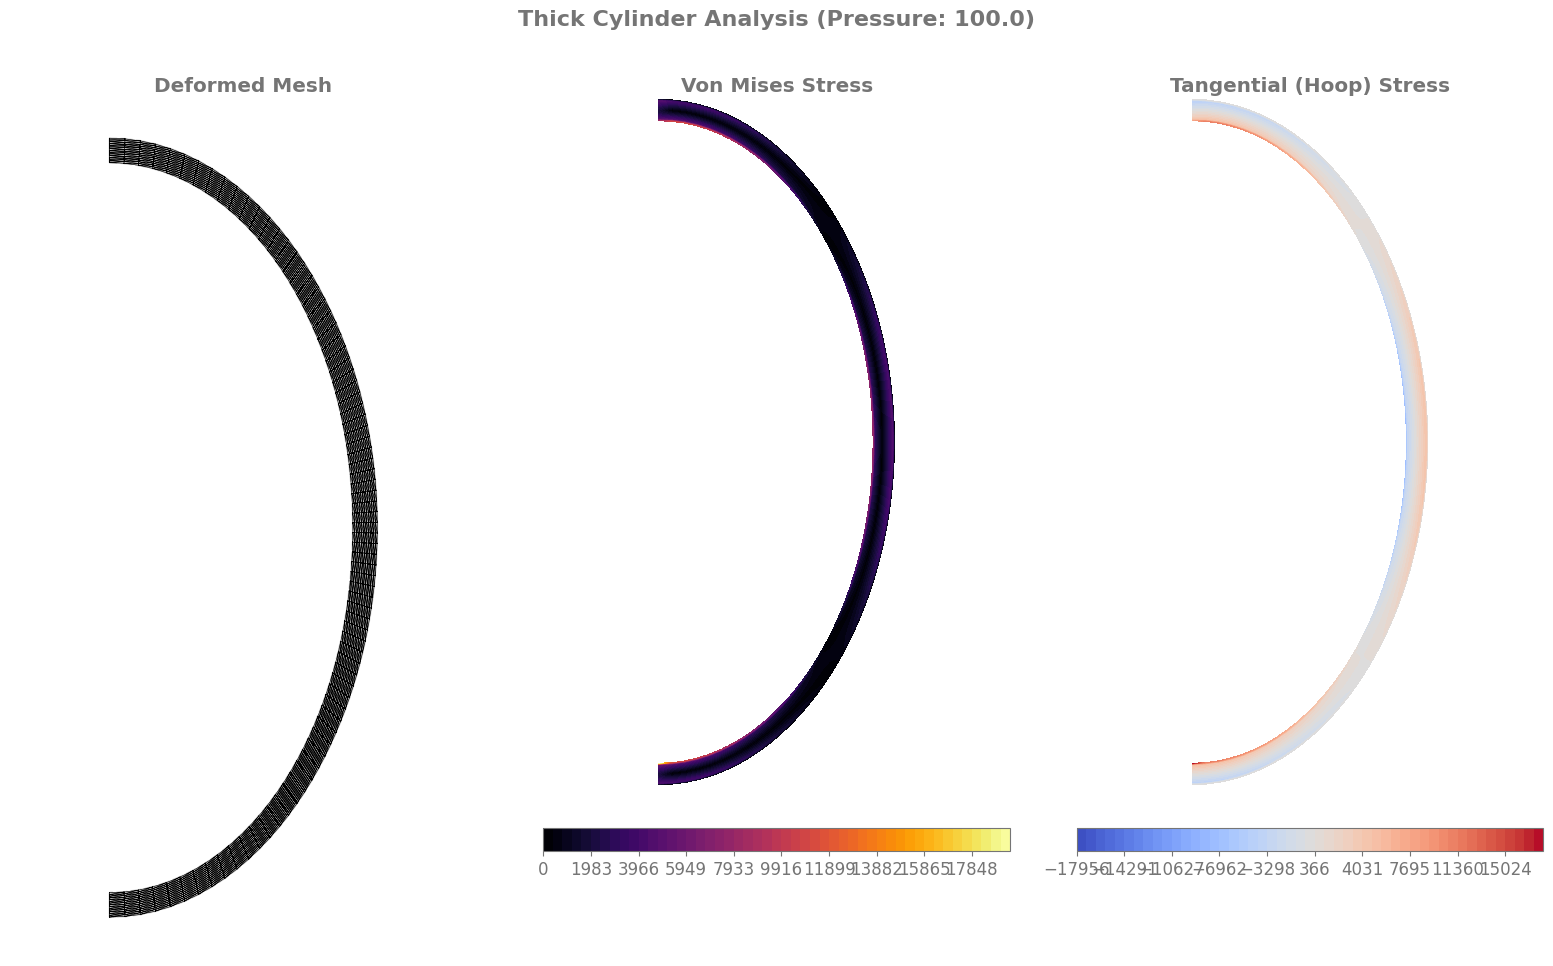

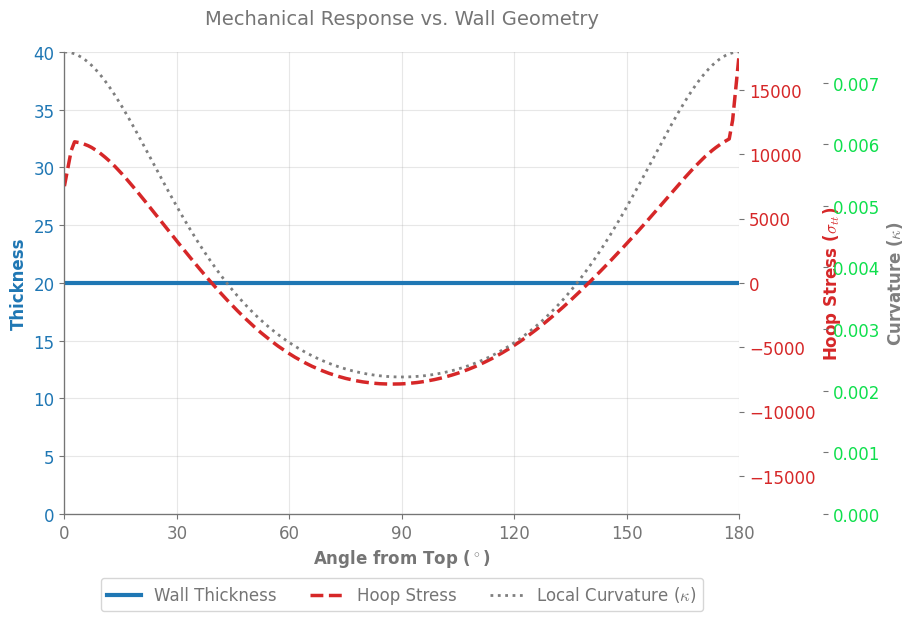

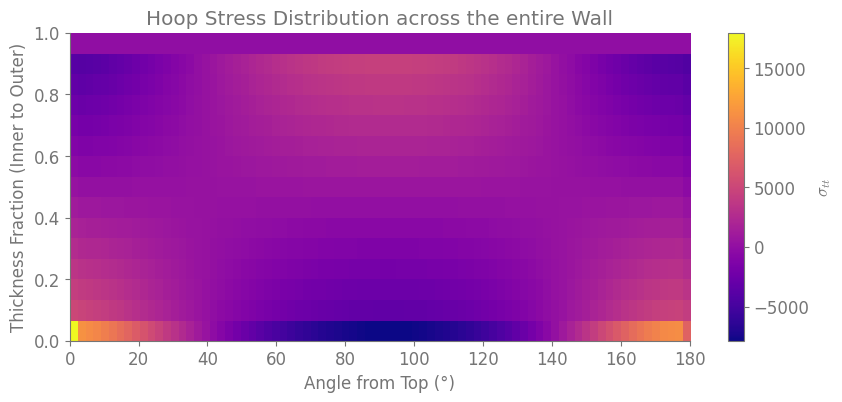

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from solidspy import solids_GUI
import solidspy.preprocesor as pre

# ==============================================================================
# 1. USER CONTROL PANEL
# ==============================================================================
# --- Geometry Parameters ---
r_i_val = 300.0*1   # Inner radius (Major axis along Y)
AR_val = 1.5   # Aspect Ratio (r_i_val / AR_val = minor axis along X)
t_top_val = 20.0*1    # Minimum thickness at top (0 deg)
t_side_val = t_top_val*1    # Maximum thickness at sides (90 deg)
t_bot_val = t_top_val*1     # Mid thickness at bottom (180 deg)

# --- Mesh Parameters ---
n_theta = 80         # Number of angular divisions (bottom to top)
n_r = 15             # Number of radial divisions (thickness)

# --- Loading ---
internal_pressure = 100.0  # Magnitude of internal pressure

# --- Material Options (Must match mater.txt) ---
# NOTE: To run this correctly as Plane Strain (thick cylinder), ensure your 
# mater.txt file uses Effective Properties: E' = E/(1-v^2), v' = v/(1-v)
# ==============================================================================

# ==============================================================================
# 2. MESH & FILE GENERATION
# ==============================================================================
def generate_and_save_model(r_i, AR, t_top, t_side, t_bot, n_t, n_r, pressure):
    """Generates half-tube mesh, BCs, and Loads, saving them for SolidSpy."""
    
    # --- A. Generate Mesh ---
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)
    
    a, b = r_i / AR, r_i
    A_t = (2*t_side + t_top + t_bot) / 4.0
    B_t = (t_top - t_bot) / 2.0
    C_t = (2*t_side - t_top - t_bot) / 4.0

    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_in = (a * b) / np.sqrt((b * np.cos(theta))**2 + (a * np.sin(theta))**2)
        t_theta = A_t + B_t * np.sin(theta) + C_t * np.cos(2*theta)
        r_out = r_in + r_frac * t_theta
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    triangles = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1, n2 = i*n_t + j, i*n_t + (j + 1)
            n3, n4 = (i + 1)*n_t + j, (i + 1)*n_t + (j + 1)
            triangles.extend([[n1, n3, n2], [n2, n3, n4]])
    triangles = np.array(triangles)

    # --- B. Save Nodes (with BCs) & Elements ---
    min_y = np.min(nodes_y)
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    with open("eles.txt", 'w') as feles:
        for i, tri in enumerate(triangles):
            feles.write(f"{i} 3 0 {tri[0]} {tri[1]} {tri[2]}\n")

    # --- C. Save Pressure Loads ---
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx = nodes_x[n2] - nodes_x[n1]
        dy = nodes_y[n2] - nodes_y[n1]
        
        # Normal pointing into the solid (dy, -dx)
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        
        F_x[n1] += 0.5 * fx_seg; F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg; F_y[n2] += 0.5 * fy_seg

    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")
                
    return nodes_x, nodes_y, triangles

# Generate files based on user inputs
X, Y, tri_elements = generate_and_save_model(
    r_i_val, AR_val, t_top_val, t_side_val, t_bot_val, n_theta, n_r, internal_pressure
)
print("Mesh, BCs, and Loads generated successfully.")


# ==============================================================================
# 3. RUN FEA (SolidSpy)
# ==============================================================================
# Ensure mater.txt exists in the working directory before running this!
disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

# Extract Results
U_x, U_y = disp[:, 0], disp[:, 1]
Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]
von_mises = np.sqrt(Sig_xx**2 - Sig_xx*Sig_yy + Sig_yy**2 + 3*Tau_xy**2)


# ==============================================================================
# 4. POST-PROCESSING (Stress Projection)
# ==============================================================================
# Calculate Tangential (Hoop) Stress based on local geometry
theta_all = np.arctan2(Y, X)
theta_in_raw = np.arctan2(Y[:n_theta], X[:n_theta])
sort_idx = np.argsort(theta_in_raw)

x_in, y_in = X[:n_theta][sort_idx], Y[:n_theta][sort_idx]
theta_in_sorted = theta_in_raw[sort_idx]

# Tangent/Normal calculation
dx_in, dy_in = np.gradient(x_in), np.gradient(y_in)
alpha_inner = np.arctan2(dy_in, dx_in) - (np.pi / 2.0)

# Map normal angle to all nodes
closest_idx = np.argmin(np.abs(theta_all[:, np.newaxis] - theta_in_sorted), axis=1)
alpha_all = alpha_inner[closest_idx]
c, s = np.cos(alpha_all), np.sin(alpha_all)

# Project Stress
Sig_tt = Sig_xx * s**2 + Sig_yy * c**2 - 2 * Tau_xy * s * c


# ==============================================================================
# 5. VISUALIZATION (Consolidated Subplots)
# ==============================================================================
fig = plt.figure(figsize=(16, 10))

# --- Subplot 1: Geometry & Deformation ---
ax1 = plt.subplot(1, 3, 1)
scale = 1  # Deformation scale factor
ax1.triplot(X, Y, tri_elements, color='gray', linestyle='--', alpha=0.3)
ax1.triplot(X + U_x*scale, Y + U_y*scale, tri_elements, color='black', lw=0.5)
ax1.set_title("Deformed Mesh", fontweight='bold')
ax1.axis('equal'); ax1.axis('off')


# --- Subplot 2: Von Mises Stress ---
ax2 = plt.subplot(1, 3, 2)
levels_vm = np.linspace(0, np.max(von_mises), 50)
cont2 = ax2.tricontourf(X, Y, tri_elements, von_mises, levels=levels_vm, cmap='inferno')
ax2.set_title("Von Mises Stress", fontweight='bold')
ax2.axis('equal'); ax2.axis('off')
fig.colorbar(cont2, ax=ax2, orientation='horizontal', pad=0.05)

# --- Subplot 3: Tangential (Hoop) Stress ---
ax3 = plt.subplot(1, 3, 3)
max_tt = np.max(np.abs(Sig_tt))
levels_tt = np.linspace(-max_tt, max_tt, 50)
cont3 = ax3.tricontourf(X, Y, tri_elements, Sig_tt, levels=levels_tt, cmap='coolwarm')
ax3.set_title("Tangential (Hoop) Stress", fontweight='bold')
ax3.axis('equal'); ax3.axis('off')
fig.colorbar(cont3, ax=ax3, orientation='horizontal', pad=0.05)

plt.suptitle(f"Thick Cylinder Analysis (Pressure: {internal_pressure})", fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()
# ==============================================================================
# 6. GEOMETRY (THICKNESS & CURVATURE) vs STRESS CORRELATION
# ==============================================================================
phi_deg = np.linspace(0, 180, 200)
theta_math = np.pi/2 - np.deg2rad(phi_deg) # Top is pi/2, Side is 0, Bottom is -pi/2

# --- 1. Extract Stress Data ---
sig_tt_in_raw = Sig_tt[:n_theta]
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw)
sort_idx2 = np.argsort(phi_in_deg_raw)
sig_tt_smooth = np.interp(phi_deg, phi_in_deg_raw[sort_idx2], sig_tt_in_raw[sort_idx2])

# --- 2. Geometry Profiles ---
# A. Thickness
A_t = (2*t_side_val + t_top_val + t_bot_val) / 4.0
B_t = (t_top_val - t_bot_val) / 2.0
C_t = (2*t_side_val - t_top_val - t_bot_val) / 4.0
thickness = A_t + B_t * np.sin(theta_math) + C_t * np.cos(2*theta_math)

# B. Local Curvature (Kappa)
a = r_i_val / AR_val  # Semi-minor axis (X)
b = r_i_val           # Semi-major axis (Y)
numerator = a * b
denominator = (a**2 * np.sin(theta_math)**2 + b**2 * np.cos(theta_math)**2)**(1.5)
kappa = numerator / denominator

# --- 3. Plotting with Triple Y-Axes ---
fig2, ax_t = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.8) # Make room for the third axis

ax_s = ax_t.twinx() # Second axis for Stress
ax_k = ax_t.twinx() # Third axis for Curvature

# Offset the third axis (Curvature) to the right
ax_k.spines['right'].set_position(('outward', 60))

# Plot lines
line1 = ax_t.plot(phi_deg, thickness, color='#1f77b4', lw=3, label='Wall Thickness')
line2 = ax_s.plot(phi_deg, sig_tt_smooth, color='#d62728', lw=2.5, ls='--', label='Hoop Stress')
line3 = ax_k.plot(phi_deg, kappa, color='#7f7f7f', lw=2, ls=':', label='Local Curvature ($\kappa$)')

# Labeling
ax_t.set_xlabel('Angle from Top ($^\circ$)', fontweight='bold')
ax_t.set_ylabel('Thickness', color='#1f77b4', fontweight='bold')
ax_s.set_ylabel('Hoop Stress ($\sigma_{tt}$)', color='#d62728', fontweight='bold')
ax_k.set_ylabel('Curvature ($\kappa$)', color='#7f7f7f', fontweight='bold')

# Colors and Ticks
ax_t.tick_params(axis='y', labelcolor='#1f77b4')
ax_s.tick_params(axis='y', labelcolor='#d62728')
ax_k.tick_params(axis='y', labelcolor="#0fdf4d")

ax_t.set_xlim(0, 180)
ax_t.set_ylim(0, np.max(thickness)*2)
ax_t.set_xticks(np.arange(0, 181, 30))
ax_t.grid(True, alpha=0.3)

ax_k.set_ylim(0, np.max(kappa))
ax_s.set_ylim(-np.max(sig_tt_smooth), np.max(sig_tt_smooth))

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_t.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('Mechanical Response vs. Wall Geometry', fontsize=14, pad=20)
plt.show()

# --- 1. Reshape the stress data into a grid ---
# This transforms Sig_tt from a flat array into a grid of [radial_layer, angular_index]
Sig_tt_grid = Sig_tt.reshape((n_r, n_theta))

# --- 2. Pick an angle to analyze ---
# Example: Index for the "Side" (approx 90 deg from top)
target_angle_deg = 90
# Map the angle back to the index j
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw) # From your previous code
j_target = np.argmin(np.abs(phi_in_deg_raw - target_angle_deg))

# --- 3. Extract the stress through the thickness at that angle ---
stress_slice = Sig_tt_grid[:, j_target]

# --- 4. Calculate radial distance for the X-axis of the plot ---
# Get the X and Y coordinates for this specific slice
x_slice = X.reshape((n_r, n_theta))[:, j_target]
y_slice = Y.reshape((n_r, n_theta))[:, j_target]

# Radial distance from the inner wall
dist_from_inner = np.sqrt((x_slice - x_slice[0])**2 + (y_slice - y_slice[0])**2)


plt.figure(figsize=(10, 4))
plt.imshow(Sig_tt_grid, aspect='auto', cmap='plasma', origin='lower',
           extent=[0, 180, 0, 1]) # 0 to 1 represents thickness fraction
plt.colorbar(label='$\sigma_{tt}$')
plt.xlabel('Angle from Top (°)')
plt.ylabel('Thickness Fraction (Inner to Outer)')
plt.title('Hoop Stress Distribution across the entire Wall')
plt.show()

Mesh, BCs, and Loads generated successfully.
Number of nodes: 1200
Number of elements: 2212
Number of equations: 2369
Duration for system solution: 0:00:01.121225
Duration for post processing: 0:00:00.374729
Analysis terminated successfully!


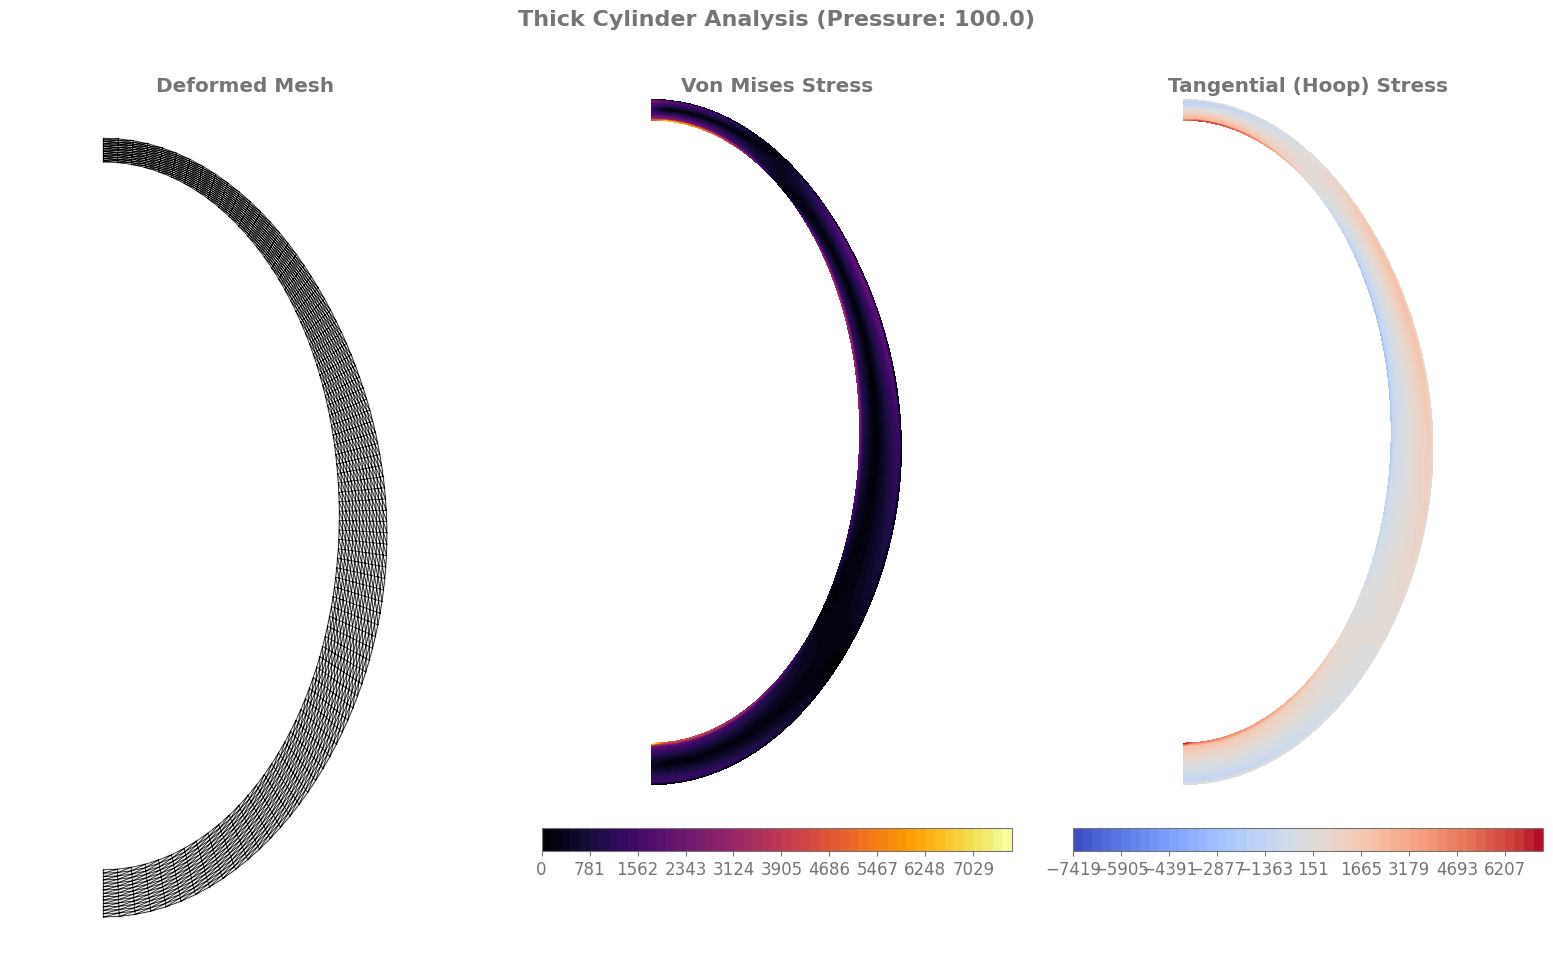

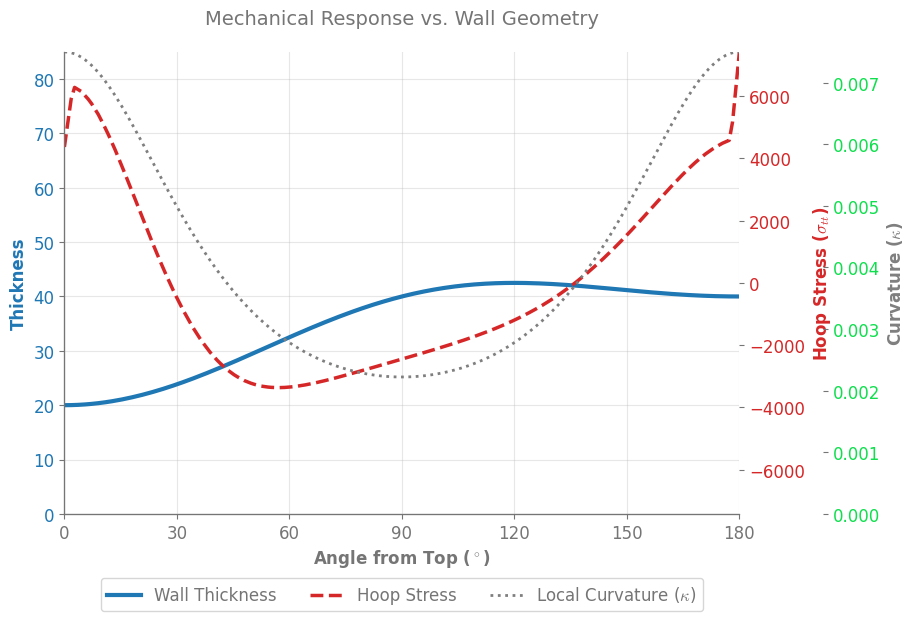

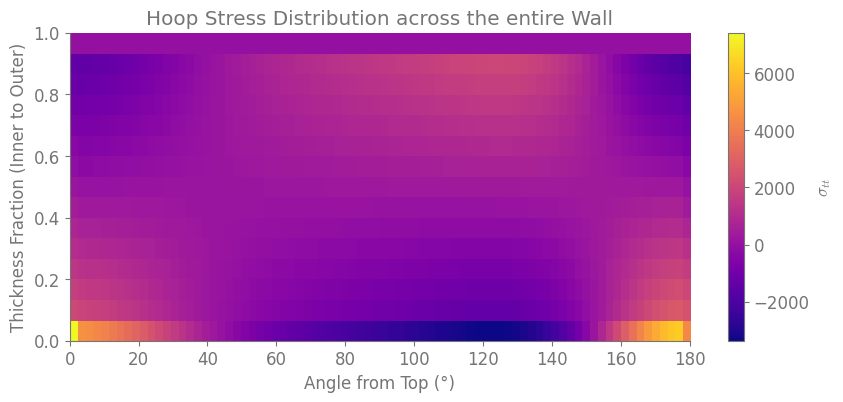

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from solidspy import solids_GUI
import solidspy.preprocesor as pre

# ==============================================================================
# 1. USER CONTROL PANEL
# ==============================================================================
# --- Geometry Parameters ---
r_i_val = 300.0*1   # Inner radius (Major axis along Y)
AR_val = 1.5   # Aspect Ratio (r_i_val / AR_val = minor axis along X)
t_top_val = 20.0*1    # Minimum thickness at top (0 deg)
t_side_val = t_top_val*2    # Maximum thickness at sides (90 deg)
t_bot_val = t_top_val*2     # Mid thickness at bottom (180 deg)

# --- Mesh Parameters ---
n_theta = 80         # Number of angular divisions (bottom to top)
n_r = 15             # Number of radial divisions (thickness)

# --- Loading ---
internal_pressure = 100.0  # Magnitude of internal pressure

# --- Material Options (Must match mater.txt) ---
# NOTE: To run this correctly as Plane Strain (thick cylinder), ensure your 
# mater.txt file uses Effective Properties: E' = E/(1-v^2), v' = v/(1-v)
# ==============================================================================

# ==============================================================================
# 2. MESH & FILE GENERATION
# ==============================================================================
def generate_and_save_model(r_i, AR, t_top, t_side, t_bot, n_t, n_r, pressure):
    """Generates half-tube mesh, BCs, and Loads, saving them for SolidSpy."""
    
    # --- A. Generate Mesh ---
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)
    
    a, b = r_i / AR, r_i
    A_t = (2*t_side + t_top + t_bot) / 4.0
    B_t = (t_top - t_bot) / 2.0
    C_t = (2*t_side - t_top - t_bot) / 4.0

    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_in = (a * b) / np.sqrt((b * np.cos(theta))**2 + (a * np.sin(theta))**2)
        t_theta = A_t + B_t * np.sin(theta) + C_t * np.cos(2*theta)
        r_out = r_in + r_frac * t_theta
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    triangles = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1, n2 = i*n_t + j, i*n_t + (j + 1)
            n3, n4 = (i + 1)*n_t + j, (i + 1)*n_t + (j + 1)
            triangles.extend([[n1, n3, n2], [n2, n3, n4]])
    triangles = np.array(triangles)

    # --- B. Save Nodes (with BCs) & Elements ---
    min_y = np.min(nodes_y)
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    with open("eles.txt", 'w') as feles:
        for i, tri in enumerate(triangles):
            feles.write(f"{i} 3 0 {tri[0]} {tri[1]} {tri[2]}\n")

    # --- C. Save Pressure Loads ---
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx = nodes_x[n2] - nodes_x[n1]
        dy = nodes_y[n2] - nodes_y[n1]
        
        # Normal pointing into the solid (dy, -dx)
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        
        F_x[n1] += 0.5 * fx_seg; F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg; F_y[n2] += 0.5 * fy_seg

    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")
                
    return nodes_x, nodes_y, triangles

# Generate files based on user inputs
X, Y, tri_elements = generate_and_save_model(
    r_i_val, AR_val, t_top_val, t_side_val, t_bot_val, n_theta, n_r, internal_pressure
)
print("Mesh, BCs, and Loads generated successfully.")


# ==============================================================================
# 3. RUN FEA (SolidSpy)
# ==============================================================================
# Ensure mater.txt exists in the working directory before running this!
disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

# Extract Results
U_x, U_y = disp[:, 0], disp[:, 1]
Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]
von_mises = np.sqrt(Sig_xx**2 - Sig_xx*Sig_yy + Sig_yy**2 + 3*Tau_xy**2)


# ==============================================================================
# 4. POST-PROCESSING (Stress Projection)
# ==============================================================================
# Calculate Tangential (Hoop) Stress based on local geometry
theta_all = np.arctan2(Y, X)
theta_in_raw = np.arctan2(Y[:n_theta], X[:n_theta])
sort_idx = np.argsort(theta_in_raw)

x_in, y_in = X[:n_theta][sort_idx], Y[:n_theta][sort_idx]
theta_in_sorted = theta_in_raw[sort_idx]

# Tangent/Normal calculation
dx_in, dy_in = np.gradient(x_in), np.gradient(y_in)
alpha_inner = np.arctan2(dy_in, dx_in) - (np.pi / 2.0)

# Map normal angle to all nodes
closest_idx = np.argmin(np.abs(theta_all[:, np.newaxis] - theta_in_sorted), axis=1)
alpha_all = alpha_inner[closest_idx]
c, s = np.cos(alpha_all), np.sin(alpha_all)

# Project Stress
Sig_tt = Sig_xx * s**2 + Sig_yy * c**2 - 2 * Tau_xy * s * c


# ==============================================================================
# 5. VISUALIZATION (Consolidated Subplots)
# ==============================================================================
fig = plt.figure(figsize=(16, 10))

# --- Subplot 1: Geometry & Deformation ---
ax1 = plt.subplot(1, 3, 1)
scale = 1  # Deformation scale factor
ax1.triplot(X, Y, tri_elements, color='gray', linestyle='--', alpha=0.3)
ax1.triplot(X + U_x*scale, Y + U_y*scale, tri_elements, color='black', lw=0.5)
ax1.set_title("Deformed Mesh", fontweight='bold')
ax1.axis('equal'); ax1.axis('off')


# --- Subplot 2: Von Mises Stress ---
ax2 = plt.subplot(1, 3, 2)
levels_vm = np.linspace(0, np.max(von_mises), 50)
cont2 = ax2.tricontourf(X, Y, tri_elements, von_mises, levels=levels_vm, cmap='inferno')
ax2.set_title("Von Mises Stress", fontweight='bold')
ax2.axis('equal'); ax2.axis('off')
fig.colorbar(cont2, ax=ax2, orientation='horizontal', pad=0.05)

# --- Subplot 3: Tangential (Hoop) Stress ---
ax3 = plt.subplot(1, 3, 3)
max_tt = np.max(np.abs(Sig_tt))
levels_tt = np.linspace(-max_tt, max_tt, 50)
cont3 = ax3.tricontourf(X, Y, tri_elements, Sig_tt, levels=levels_tt, cmap='coolwarm')
ax3.set_title("Tangential (Hoop) Stress", fontweight='bold')
ax3.axis('equal'); ax3.axis('off')
fig.colorbar(cont3, ax=ax3, orientation='horizontal', pad=0.05)

plt.suptitle(f"Thick Cylinder Analysis (Pressure: {internal_pressure})", fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()
# ==============================================================================
# 6. GEOMETRY (THICKNESS & CURVATURE) vs STRESS CORRELATION
# ==============================================================================
phi_deg = np.linspace(0, 180, 200)
theta_math = np.pi/2 - np.deg2rad(phi_deg) # Top is pi/2, Side is 0, Bottom is -pi/2

# --- 1. Extract Stress Data ---
sig_tt_in_raw = Sig_tt[:n_theta]
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw)
sort_idx2 = np.argsort(phi_in_deg_raw)
sig_tt_smooth = np.interp(phi_deg, phi_in_deg_raw[sort_idx2], sig_tt_in_raw[sort_idx2])

# --- 2. Geometry Profiles ---
# A. Thickness
A_t = (2*t_side_val + t_top_val + t_bot_val) / 4.0
B_t = (t_top_val - t_bot_val) / 2.0
C_t = (2*t_side_val - t_top_val - t_bot_val) / 4.0
thickness = A_t + B_t * np.sin(theta_math) + C_t * np.cos(2*theta_math)

# B. Local Curvature (Kappa)
a = r_i_val / AR_val  # Semi-minor axis (X)
b = r_i_val           # Semi-major axis (Y)
numerator = a * b
denominator = (a**2 * np.sin(theta_math)**2 + b**2 * np.cos(theta_math)**2)**(1.5)
kappa = numerator / denominator

# --- 3. Plotting with Triple Y-Axes ---
fig2, ax_t = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.8) # Make room for the third axis

ax_s = ax_t.twinx() # Second axis for Stress
ax_k = ax_t.twinx() # Third axis for Curvature

# Offset the third axis (Curvature) to the right
ax_k.spines['right'].set_position(('outward', 60))

# Plot lines
line1 = ax_t.plot(phi_deg, thickness, color='#1f77b4', lw=3, label='Wall Thickness')
line2 = ax_s.plot(phi_deg, sig_tt_smooth, color='#d62728', lw=2.5, ls='--', label='Hoop Stress')
line3 = ax_k.plot(phi_deg, kappa, color='#7f7f7f', lw=2, ls=':', label='Local Curvature ($\kappa$)')

# Labeling
ax_t.set_xlabel('Angle from Top ($^\circ$)', fontweight='bold')
ax_t.set_ylabel('Thickness', color='#1f77b4', fontweight='bold')
ax_s.set_ylabel('Hoop Stress ($\sigma_{tt}$)', color='#d62728', fontweight='bold')
ax_k.set_ylabel('Curvature ($\kappa$)', color='#7f7f7f', fontweight='bold')

# Colors and Ticks
ax_t.tick_params(axis='y', labelcolor='#1f77b4')
ax_s.tick_params(axis='y', labelcolor='#d62728')
ax_k.tick_params(axis='y', labelcolor="#0fdf4d")

ax_t.set_xlim(0, 180)
ax_t.set_ylim(0, np.max(thickness)*2)
ax_t.set_xticks(np.arange(0, 181, 30))
ax_t.grid(True, alpha=0.3)

ax_k.set_ylim(0, np.max(kappa))
ax_s.set_ylim(-np.max(sig_tt_smooth), np.max(sig_tt_smooth))

# Combined Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax_t.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.title('Mechanical Response vs. Wall Geometry', fontsize=14, pad=20)
plt.show()

# --- 1. Reshape the stress data into a grid ---
# This transforms Sig_tt from a flat array into a grid of [radial_layer, angular_index]
Sig_tt_grid = Sig_tt.reshape((n_r, n_theta))

# --- 2. Pick an angle to analyze ---
# Example: Index for the "Side" (approx 90 deg from top)
target_angle_deg = 90
# Map the angle back to the index j
phi_in_deg_raw = 90.0 - np.degrees(theta_in_raw) # From your previous code
j_target = np.argmin(np.abs(phi_in_deg_raw - target_angle_deg))

# --- 3. Extract the stress through the thickness at that angle ---
stress_slice = Sig_tt_grid[:, j_target]

# --- 4. Calculate radial distance for the X-axis of the plot ---
# Get the X and Y coordinates for this specific slice
x_slice = X.reshape((n_r, n_theta))[:, j_target]
y_slice = Y.reshape((n_r, n_theta))[:, j_target]

# Radial distance from the inner wall
dist_from_inner = np.sqrt((x_slice - x_slice[0])**2 + (y_slice - y_slice[0])**2)


plt.figure(figsize=(10, 4))
plt.imshow(Sig_tt_grid, aspect='auto', cmap='plasma', origin='lower',
           extent=[0, 180, 0, 1]) # 0 to 1 represents thickness fraction
plt.colorbar(label='$\sigma_{tt}$')
plt.xlabel('Angle from Top (°)')
plt.ylabel('Thickness Fraction (Inner to Outer)')
plt.title('Hoop Stress Distribution across the entire Wall')
plt.show()